<center> Import Libary </center>

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import string

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder
from collections import Counter
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import f1_score

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

<Center> ML Libaries </center>

---

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import StackingClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Concatenate
from tensorflow.keras.models import Model
from google.colab import drive

<center> Randomize Seed </center>

---

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

<center> Load Dataset </center>

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def detect_features_from_text(text):
    text = str(text).lower()

    # URL Detect
    url_pattern = r'http\S+|www\.\S+|https\S+|\w+\.(com|net|org|edu|gov|co\.\w+)'
    has_url = 'yes' if re.search(url_pattern, text) else 'no'

    # Email Deetect
    email_pattern = r'\S+@\S+\.\S+'
    has_email = 'yes' if re.search(email_pattern, text) else 'no'

    # Phone Detect
    phone_pattern = r'\b\d{10,}\b|[\+\(]?\d[\d\-\.\s\(\)]{8,}\d'
    has_phone = 'yes' if re.search(phone_pattern, text) else 'no'

    return has_url, has_email, has_phone

In [ ]:
# Load Dataset 1: Dataset_5971.csv
print("Loading Dataset_5971.csv...")
df1 = pd.read_csv('/content/drive/MyDrive/Dataset/Dataset_5971.csv')
df1['LABEL'] = df1['LABEL'].str.lower()  # Normalize to lowercase
print(f"  Dataset_5971: {df1.shape[0]} rows")
print(f"  Labels: {df1['LABEL'].value_counts().to_dict()}")

# Load Dataset 2: Dataset_10191.csv
print("\nLoading Dataset_10191.csv...")
df2 = pd.read_csv('/content/drive/MyDrive/Dataset/Dataset_10191.csv')
df2['LABEL'] = df2['LABEL'].str.lower()  # Normalize to lowercase
print(f"  Dataset_10191: {df2.shape[0]} rows")
print(f"  Labels: {df2['LABEL'].value_counts().to_dict()}")

# Load Dataset 3: Combined-Labeled-Dataset.csv
print("\nLoading Combined-Labeled-Dataset.csv...")
df3 = pd.read_csv('/content/drive/MyDrive/Dataset/Combined-Labeled-Dataset.csv')

# Rename 'message' to 'TEXT' for consistency
df3 = df3.rename(columns={'message': 'TEXT'})

# Strip whitespace from column names (in case there are extra spaces)
df3.columns = df3.columns.str.strip()

print(f"  Column names: {df3.columns.tolist()}")
print(f"  Data types:\n{df3[['spam label', 'smishing label']].dtypes}")
print(f"\n  First 5 rows of labels:")
print(df3[['spam label', 'smishing label']].head())
print(f"\n  Unique values in 'spam label': {df3['spam label'].unique()}")
print(f"\n  Unique values in 'smishing label': {df3['smishing label'].unique()}")

# Convert to numeric and handle any string values
df3['spam label'] = pd.to_numeric(df3['spam label'], errors='coerce').fillna(0).astype(int)
df3['smishing label'] = pd.to_numeric(df3['smishing label'], errors='coerce').fillna(0).astype(int)

# Map labels based on spam and smishing columns
def map_label(row):
    spam = int(row['spam label'])
    smishing = int(row['smishing label'])

    if spam == 0 and smishing == 0:
        return 'ham'
    elif spam == 1 and smishing == 0:
        return 'spam'
    elif spam == 0 and smishing == 1:
        return 'smishing'
    elif spam == 1 and smishing == 1:
        return 'smishing'  # Both spam and smishing -> prioritize smishing
    else:
        return 'unknown'  # Just in case

df3['LABEL'] = df3.apply(map_label, axis=1)

# Check if there are still unknowns
unknown_count = (df3['LABEL'] == 'unknown').sum()
if unknown_count > 0:
    print(f"\n  WARNING: {unknown_count} rows marked as 'unknown'")
    print("  Sample of unknown rows:")
    print(df3[df3['LABEL'] == 'unknown'][['TEXT', 'spam label', 'smishing label', 'LABEL']].head())
else:
    print(f"\n  ✓ All labels mapped successfully!")

# Detect URL, EMAIL, PHONE from TEXT
print("  Detecting URL, EMAIL, PHONE from text...")
detected_features = df3['TEXT'].apply(detect_features_from_text)
df3['URL'] = [x[0] for x in detected_features]
df3['EMAIL'] = [x[1] for x in detected_features]
df3['PHONE'] = [x[2] for x in detected_features]

# Drop original spam/smishing label columns
df3 = df3.drop(columns=['spam label', 'smishing label'])

print(f"  Combined-Labeled-Dataset: {df3.shape[0]} rows")
print(f"  Labels: {df3['LABEL'].value_counts().to_dict()}")
print(f"  Detected - URL: {(df3['URL']=='yes').sum()}, EMAIL: {(df3['EMAIL']=='yes').sum()}, PHONE: {(df3['PHONE']=='yes').sum()}")

# Combine all three datasets
print("\n" + "="*80)
print("COMBINING ALL DATASETS")
print("="*80)

df = pd.concat([df1, df2, df3], ignore_index=True)

print(f"\nCombined Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print("\nLabel Distribution:")
print(df['LABEL'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())

Loading Dataset_5971.csv...
  Dataset_5971: 5971 rows
  Labels: {'ham': 4844, 'smishing': 638, 'spam': 489}

Loading Dataset_10191.csv...
  Dataset_10191: 10191 rows
  Labels: {'ham': 3397, 'smishing': 3397, 'spam': 3397}

Loading Combined-Labeled-Dataset.csv...
  Column names: ['TEXT', 'spam label', 'smishing label']
  Data types:
spam label        object
smishing label     int64
dtype: object

  First 5 rows of labels:
  spam label  smishing label
0          1               0
1          1               0
2          1               0
3          1               0
4          1               0

  Unique values in 'spam label': ['1' '0' nan 'Smishing']

  Unique values in 'smishing label': [0 1]

  ✓ All labels mapped successfully!
  Detecting URL, EMAIL, PHONE from text...
  Combined-Labeled-Dataset: 84863 rows
  Labels: {'ham': 53647, 'smishing': 24086, 'spam': 7130}
  Detected - URL: 12048, EMAIL: 173, PHONE: 3348

COMBINING ALL DATASETS

Combined Dataset Shape: (101025, 5)

Column Nam

<center> Pre-processing Data </center>

---

<h4> Remove spam Label <h4>

In [ ]:
# Normalize
df['LABEL'] = df['LABEL'].str.lower()
print("Before removing SPAM:")
print(df['LABEL'].value_counts())

# Remove Spam
df = df[df['LABEL'] != 'spam'].copy()
df = df.reset_index(drop=True)

print("\nAfter removing SPAM:")
print(df['LABEL'].value_counts())
print(f"Remaining data: {df.shape[0]} rows")

Before removing SPAM:
LABEL
ham         61888
smishing    28121
spam        11016
Name: count, dtype: int64

After removing SPAM:
LABEL
ham         61888
smishing    28121
Name: count, dtype: int64
Remaining data: 90009 rows


<h4> Handle Missing Value <h4>

In [ ]:
# Remove NaN files
df = df.dropna(subset=['TEXT'])
df['TEXT'] = df['TEXT'].astype(str)

# fill no for url,email,phone in dataset
for col in ['URL', 'EMAIL', 'PHONE']:
    if col in df.columns:
        df[col] = df[col].fillna('no').str.lower()

print(f"After: {df.shape}")
print("\nMissing values after handling:")
print(df.isnull().sum())

After: (90009, 5)

Missing values after handling:
LABEL    0
TEXT     0
URL      0
EMAIL    0
PHONE    0
dtype: int64


<h4> Clean Text <h4>

In [ ]:
def clean_text(text):
    # Remove URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remvoe Email
    text = re.sub(r'\S+@\S+', '', text)
    # Remvoe Phone
    text = re.sub(r'\b\d{10,}\b', '', text)
    text = re.sub(r'[\+\(]?\d[\d\-\.\s\(\)]+\d', '', text)
    # Remove Reptition words
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)
    # Remove special
    text = re.sub(r'[^a-zA-Z0-9\s!?]', '', text)
    # Remove whitespace that more than 1
    text = ' '.join(text.split())
    return text

df['TEXT_CLEANED'] = df['TEXT'].apply(clean_text)

# remove empty string
before_len = len(df)
df = df[df['TEXT_CLEANED'].str.strip() != ''].reset_index(drop=True)
after_len = len(df)

print(f"Rows before cleaning: {before_len}")
print(f"Rows after cleaning: {after_len}")
print(f"Removed {before_len - after_len} empty rows")

Rows before cleaning: 90009
Rows after cleaning: 89951
Removed 58 empty rows


<h4> Case Folding <h4>

In [ ]:
def case_folding(text):
  return text.lower()

df['TEXT_CASEFOLDED'] = df['TEXT_CLEANED'].apply(case_folding)

In [ ]:
print("Examples after Case Folding:")
print(df[['TEXT_CLEANED', 'TEXT_CASEFOLDED']].head(3))

Examples after Case Folding:
                                        TEXT_CLEANED  \
0  Your opinion about me? 1 Over 2 Jada 3 Kusruth...   
1  Whats up? Do you want me to come online? If yo...   
2                       So u workin overtime nigpun?   

                                     TEXT_CASEFOLDED  
0  your opinion about me? 1 over 2 jada 3 kusruth...  
1  whats up? do you want me to come online? if yo...  
2                       so u workin overtime nigpun?  


<h4> Tokenization <h4>

In [ ]:
def tokenization(text):
  return word_tokenize(text)

df['TEXT_TOKENS'] = df['TEXT_CASEFOLDED'].apply(tokenization)

In [ ]:
print("Examples after tokenization:")
print(df[['TEXT_CASEFOLDED', 'TEXT_TOKENS']].head(3))

Examples after tokenization:
                                     TEXT_CASEFOLDED  \
0  your opinion about me? 1 over 2 jada 3 kusruth...   
1  whats up? do you want me to come online? if yo...   
2                       so u workin overtime nigpun?   

                                         TEXT_TOKENS  
0  [your, opinion, about, me, ?, 1, over, 2, jada...  
1  [whats, up, ?, do, you, want, me, to, come, on...  
2               [so, u, workin, overtime, nigpun, ?]  


<h4> StopWord <h4

In [ ]:
stop_words = set(stopwords.words('english'))

# Keep some important word (may increase later ?)
important_words = {'urgent', 'free', 'win', 'claim', 'now', 'limited',
                   'you', 'your', 'click', 'verify', 'account', 'expire',
                   'act', 'immediate', 'congratulations', 'prize', 'won'}

# Costum stop word
custom_stops = stop_words - important_words

def remove_stopwords_minimal(tokens):
    filtered_tokens = [
        word for word in tokens
        if (word.lower() not in custom_stops and len(word) > 2) or word.lower() in important_words
    ]
    return filtered_tokens

df['TEXT_FILTERED'] = df['TEXT_TOKENS'].apply(remove_stopwords_minimal)

In [ ]:
print("Examples after stopword removal:")
print(df[['TEXT_TOKENS', 'TEXT_FILTERED']].head(3))

print(f"\nAverage tokens before stopword removal: {df['TEXT_TOKENS'].apply(len).mean():.2f}")
print(f"Average tokens after stopword removal: {df['TEXT_FILTERED'].apply(len).mean():.2f}")

Examples after stopword removal:
                                         TEXT_TOKENS  \
0  [your, opinion, about, me, ?, 1, over, 2, jada...   
1  [whats, up, ?, do, you, want, me, to, come, on...   
2               [so, u, workin, overtime, nigpun, ?]   

                                       TEXT_FILTERED  
0  [your, opinion, jada, kusruthi, lovable, silen...  
1  [whats, you, want, come, online, you, free, ta...  
2                         [workin, overtime, nigpun]  

Average tokens before stopword removal: 17.04
Average tokens after stopword removal: 10.16


<h4> Lemmatization <h4>

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['TEXT_LEMMATIZED'] = df['TEXT_FILTERED'].apply(lemmatize_tokens)

In [ ]:
print("Example after lemmatization:")
print(df[['TEXT_FILTERED', 'TEXT_LEMMATIZED']].head(3))

Example after lemmatization:
                                       TEXT_FILTERED  \
0  [your, opinion, jada, kusruthi, lovable, silen...   
1  [whats, you, want, come, online, you, free, ta...   
2                         [workin, overtime, nigpun]   

                                     TEXT_LEMMATIZED  
0  [your, opinion, jada, kusruthi, lovable, silen...  
1  [whats, you, want, come, online, you, free, ta...  
2                         [workin, overtime, nigpun]  


<h4> FINAL <h4>

In [ ]:
df['TEXT_PROCESSED'] = df['TEXT_LEMMATIZED'].apply(lambda x: ' '.join(x))

df = df[df['TEXT_PROCESSED'].str.strip() != ''].reset_index(drop=True)

print("Available columns:", list(df.columns))

Available columns: ['LABEL', 'TEXT', 'URL', 'EMAIL', 'PHONE', 'TEXT_CLEANED', 'TEXT_CASEFOLDED', 'TEXT_TOKENS', 'TEXT_FILTERED', 'TEXT_LEMMATIZED', 'TEXT_PROCESSED']


<center> Feature Engineering </center>

---

<h4> Encode Binary Features <h4>

In [ ]:
# Conver yes/no to 0/1
for col in ['URL', 'EMAIL', 'PHONE']:
    df[f'{col}_BINARY'] = df[col].map({'yes': 1, 'no': 0}).fillna(0).astype(int)

print("Binary features created:")
print(df[['URL', 'URL_BINARY', 'EMAIL', 'EMAIL_BINARY', 'PHONE', 'PHONE_BINARY']].head(10))

Binary features created:
   URL  URL_BINARY EMAIL  EMAIL_BINARY PHONE  PHONE_BINARY
0   no           0    no             0    no             0
1   no           0    no             0    no             0
2   no           0    no             0    no             0
3   no           0    no             0    no             0
4   no           0    no             0    no             0
5  yes           1    no             0   yes             1
6   no           0    no             0    no             0
7   no           0    no             0    no             0
8   no           0    no             0    no             0
9   no           0    no             0    no             0


<h4> Encode Label <h4>

In [ ]:
# Encode labels: ham=0, smishing=1
label_encoder = LabelEncoder()
df['LABEL_ENCODED'] = label_encoder.fit_transform(df['LABEL'])

print("Label Mapping:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"  {label}: {idx}")

print("\nLabel distribution after encoding:")
label_counts = df['LABEL_ENCODED'].value_counts().sort_index()
for idx, count in label_counts.items():
    label_name = label_encoder.classes_[idx]
    print(f"  {label_name} ({idx}): {count}")


Label Mapping:
  ham: 0
  smishing: 1

Label distribution after encoding:
  ham (0): 61462
  smishing (1): 28121


<h4> Addtional Feature Extraction (For Meta-patterns) <h4>

In [ ]:
def extract_text_features(text):
    features = {}

    features['char_count'] = len(text)
    features['word_count'] = len(text.split())
    features['avg_word_length'] = np.mean([len(word) for word in text.split()]) if text.split() else 0
    features['sentence_count'] = len(re.split(r'[.!?]+', text))

    features['uppercase_ratio'] = sum(1 for c in text if c.isupper()) / len(text) if len(text) > 0 else 0
    features['uppercase_word_count'] = sum(1 for word in text.split() if word.isupper() and len(word) > 1)

    features['exclamation_count'] = text.count('!')
    features['question_count'] = text.count('?')
    features['dollar_count'] = text.count('$')
    features['special_char_count'] = sum(1 for c in text if c in string.punctuation)

    features['digit_ratio'] = sum(1 for c in text if c.isdigit()) / len(text) if len(text) > 0 else 0

    urgency_words = ['urgent', 'now', 'immediately', 'act', 'limited', 'expire', 'hurry', 'fast', 'quick']
    suspicious_words = ['free', 'win', 'winner', 'claim', 'prize', 'congratulations', 'click', 'verify',
                       'account', 'suspended', 'locked', 'confirm', 'update', 'secure', 'bonus']

    text_lower = text.lower()
    features['urgency_word_count'] = sum(1 for word in urgency_words if word in text_lower)
    features['suspicious_word_count'] = sum(1 for word in suspicious_words if word in text_lower)

    features['repeated_punctuation'] = len(re.findall(r'[!?]{2,}', text))
    features['excessive_caps'] = len(re.findall(r'\b[A-Z]{3,}\b', text))

    words = text.split()
    content_words = [word for word in words if word.lower() not in stopwords.words('english') and len(word) > 2]
    features['lexical_density'] = len(content_words) / len(words) if len(words) > 0 else 0

    return features

<h4> Text Vectorization - TF-IDF <h4>

In [ ]:
import pandas as pd
from sklearn.model_selection import cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import MinMaxScaler, Normalizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack, csr_matrix
import numpy as np

In [ ]:
text_features_list = df['TEXT'].apply(extract_text_features)
text_features_df = pd.DataFrame(text_features_list.tolist())

In [ ]:
df_sample = df.sample(n=10000, random_state=42)
MAX_FEATURES = 5000

<h4> Text Vectorization - TF-IDF <h4>

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)
X_tfidf = tfidf_vectorizer.fit_transform(df['TEXT_PROCESSED'])

<h4> Text Vectorization - Count Vectorizer <h4>

In [ ]:
count_vectorizer = CountVectorizer(max_features=MAX_FEATURES)
X_count = count_vectorizer.fit_transform(df['TEXT_PROCESSED'])

<h4> Text Vectorization - TF-IDF + N-gram <h4>

In [ ]:
tfidf_ngram_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=MAX_FEATURES)
X_tfidf_ngram = tfidf_ngram_vectorizer.fit_transform(df['TEXT_PROCESSED'])

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix, hstack
import pandas as pd
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression

print("Fitting a scaler on the full text_features_df...")
scaler = StandardScaler()
scaler.fit(text_features_df)
print("Scaler has been fitted.\n")

if 'df_sample' not in locals():
    print("Creating a data sample of 10,000 rows for speed...")
    df_sample = df.sample(n=10000, random_state=42)
    print("Sample created.\n")

# Create the feature matrices
text_features_scaled = scaler.transform(text_features_df)
text_features_sparse = csr_matrix(text_features_scaled)
binary_features = df[['URL_BINARY', 'EMAIL_BINARY', 'PHONE_BINARY']].values
binary_features_sparse = csr_matrix(binary_features)

X_method1 = hstack([X_tfidf, text_features_sparse, binary_features_sparse])
X_method2 = hstack([X_count, text_features_sparse, binary_features_sparse])
X_method3 = hstack([X_tfidf_ngram, text_features_sparse, binary_features_sparse])
X_method4 = hstack([X_tfidf, X_count, text_features_sparse, binary_features_sparse])
X_method5 = hstack([X_tfidf, X_tfidf_ngram, text_features_sparse, binary_features_sparse])
X_method6 = hstack([X_count, X_tfidf_ngram, text_features_sparse, binary_features_sparse])

vectorization_methods = {
    'Method 1: TF-IDF': X_method1,
    'Method 2: Count': X_method2,
    'Method 3: TF-IDF N-gram': X_method3,
    'Method 4: TF-IDF+Count': X_method4,
    'Method 5: TF-IDF+TF-IDF N-gram': X_method5,
    'Method 6: Count+TF-IDF N-gram': X_method6
}

y_sample = df_sample['LABEL_ENCODED'].values
vectorization_results = {}
scoring_metrics = ['f1_weighted', 'precision_weighted', 'recall_weighted']

for method_name, X_data in vectorization_methods.items():
    X_data_sample = X_data[df_sample.index]

    print(f"Testing {method_name}...")
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', solver='saga', n_jobs=-1, tol=1e-3)
    scores = cross_validate(lr, X_data_sample, y_sample, cv=5, scoring=scoring_metrics, n_jobs=-1)

    vectorization_results[method_name] = {
        'f1_mean': scores['test_f1_weighted'].mean(),
        'f1_std': scores['test_f1_weighted'].std(),
        'precision_mean': scores['test_precision_weighted'].mean(),
        'recall_mean': scores['test_recall_weighted'].mean()
    }
    print(f"  F1: {scores['test_f1_weighted'].mean():.4f} (±{scores['test_f1_weighted'].std():.4f})")

best_method_name = max(vectorization_results.items(), key=lambda x: x[1]['f1_mean'])[0]

print("\n" + "="*60)
print(f" BEST METHOD (found using the sample): {best_method_name}")
print(f" F1-Score on sample: {vectorization_results[best_method_name]['f1_mean']:.4f}")
print("="*60 + "\n")

X_final = vectorization_methods[best_method_name]
print(f"Full dataset vectorization complete using '{best_method_name}'.")
print(f"Shape of X_final is now: {X_final.shape}")

Fitting a scaler on the full text_features_df...
Scaler has been fitted.

Testing Method 1: TF-IDF...
  F1: 0.9555 (±0.0024)
Testing Method 2: Count...
  F1: 0.9675 (±0.0011)
Testing Method 3: TF-IDF N-gram...
  F1: 0.9555 (±0.0023)
Testing Method 4: TF-IDF+Count...
  F1: 0.9679 (±0.0013)
Testing Method 5: TF-IDF+TF-IDF N-gram...
  F1: 0.9584 (±0.0029)
Testing Method 6: Count+TF-IDF N-gram...
  F1: 0.9676 (±0.0014)

 BEST METHOD (found using the sample): Method 4: TF-IDF+Count
 F1-Score on sample: 0.9679

Full dataset vectorization complete using 'Method 4: TF-IDF+Count'.
Shape of X_final is now: (89583, 10019)


<h4> Train-Test Split <h4>

In [ ]:
y = df['LABEL_ENCODED'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining label distribution (Before SMOTE):")
label_counts = pd.Series(y_train).value_counts().sort_index()
for label_idx, count in label_counts.items():
    label_name = label_encoder.classes_[label_idx]
    print(f"  {label_name} ({label_idx}): {count}")

Training set: 71666 samples
Test set: 17917 samples

Training label distribution (Before SMOTE):
  ham (0): 49169
  smishing (1): 22497


SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression

smote = SMOTE(random_state=42)

print("\nApplying SMOTE to the training data...")
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("SMOTE application complete.")

print("\nLabel distribution (After SMOTE):")
label_counts_smote = pd.Series(y_train_smote).value_counts().sort_index()
for label_idx, count in label_counts_smote.items():
    label_name = label_encoder.classes_[label_idx]
    print(f"  {label_name} ({label_idx}): {count}")

print(f"\nTraining set size changed from {X_train.shape[0]} to {X_train_smote.shape[0]}")

# --- Comparison Logic ---
print("\n" + "="*50)
print("Comparing model performance with and without SMOTE...")
print("="*50)

target_names = label_encoder.classes_

# 1. Model WITHOUT SMOTE
print("\nTraining Logistic Regression WITHOUT SMOTE...")
lr_no_smote = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1)
lr_no_smote.fit(X_train, y_train)
y_pred_no_smote = lr_no_smote.predict(X_test)

print("\nClassification Report (WITHOUT SMOTE):")
print(classification_report(y_test, y_pred_no_smote, target_names=target_names))

# 2. Model WITH SMOTE
print("\nTraining Logistic Regression WITH SMOTE...")
lr_with_smote = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1) # No class_weight needed
lr_with_smote.fit(X_train_smote, y_train_smote)
y_pred_with_smote = lr_with_smote.predict(X_test)

print("\nClassification Report (WITH SMOTE):")
print(classification_report(y_test, y_pred_with_smote, target_names=target_names))

# --- Final Decision ---
f1_no_smote = f1_score(y_test, y_pred_no_smote, average='weighted')
f1_with_smote = f1_score(y_test, y_pred_with_smote, average='weighted')

print("\n" + "="*50)
print("F1-Score Comparison")
print("="*50)
print(f"  F1-Score without SMOTE: {f1_no_smote:.4f}")
print(f"  F1-Score with SMOTE:    {f1_with_smote:.4f}")

if f1_with_smote > f1_no_smote:
    improvement = ((f1_with_smote - f1_no_smote) / f1_no_smote * 100)
    print(f"\n  Improvement: +{improvement:.2f}%")
    print("Using SMOTE for the final models.")
    X_train_final = X_train_smote
    y_train_final = y_train_smote
else:
    decrease = abs(((f1_with_smote - f1_no_smote) / f1_no_smote * 100))
    print(f"\n  Decrease: -{decrease:.2f}%")
    print("NOT using SMOTE for the final models.")
    X_train_final = X_train
    y_train_final = y_train


Applying SMOTE to the training data...
SMOTE application complete.

Label distribution (After SMOTE):
  ham (0): 49169
  smishing (1): 49169

Training set size changed from 71666 to 98338

Comparing model performance with and without SMOTE...

Training Logistic Regression WITHOUT SMOTE...

Classification Report (WITHOUT SMOTE):
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99     12293
    smishing       0.97      0.98      0.97      5624

    accuracy                           0.98     17917
   macro avg       0.98      0.98      0.98     17917
weighted avg       0.98      0.98      0.98     17917


Training Logistic Regression WITH SMOTE...

Classification Report (WITH SMOTE):
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99     12293
    smishing       0.97      0.98      0.97      5624

    accuracy                           0.98     17917
   macro avg       0.98      0.98      0.98

<center> Model Development </center>

---

<h1> Machine Learning </h1>

In [ ]:
ml_results = {}

<h4> Logistic Regression <h4>

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

print("="*80)
print("LOGISTIC REGRESSION WITH HYPERPARAMETER TUNING")
print("="*80)

param_dist_lr = {
    'C': loguniform(0.01, 10),
    'solver': ['saga', 'lbfgs'],
    'max_iter': [500, 1000],
    'tol': [1e-3, 1e-4]
}

lr_base = LogisticRegression(random_state=42, n_jobs=-1)

random_search_lr = RandomizedSearchCV(
    lr_base,
    param_distributions=param_dist_lr,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting hyperparameter tuning...")
random_search_lr.fit(X_train_final, y_train_final)

print(f"\nBest parameters: {random_search_lr.best_params_}")
print(f"Best CV F1-Score: {random_search_lr.best_score_:.4f}")

lr_model = random_search_lr.best_estimator_

cv_results = cross_validate(
    lr_model,
    X_train_final,
    y_train_final,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        'f1': 'f1_weighted',
        'precision': 'precision_weighted',
        'recall': 'recall_weighted',
        'accuracy': 'accuracy'
    },
    n_jobs=-1,
    verbose=0
)

print("\nCross-Validation Results:")
print(f"  CV F1-Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"  CV Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"  CV Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"  CV Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")

print("\nTraining on full training set...")
y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision, lr_recall, lr_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_lr, average='weighted', zero_division=0
)

ml_results['Logistic Regression'] = {
    'model': lr_model,
    'predictions': y_pred_lr,
    'accuracy': lr_accuracy,
    'precision': lr_precision,
    'recall': lr_recall,
    'f1': lr_f1,
    'cv_f1_mean': cv_results['test_f1'].mean(),
    'cv_f1_std': cv_results['test_f1'].std(),
    'best_params': random_search_lr.best_params_
}

print(f"\nTest Set Results:")
print(f"  Accuracy:  {lr_accuracy:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall:    {lr_recall:.4f}")
print(f"  F1-Score:  {lr_f1:.4f}")

LOGISTIC REGRESSION WITH HYPERPARAMETER TUNING
Starting hyperparameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters: {'C': np.float64(6.541210527692731), 'max_iter': 1000, 'solver': 'lbfgs', 'tol': 0.0001}
Best CV F1-Score: 0.9843

Cross-Validation Results:
  CV F1-Score:  0.9843 ± 0.0018
  CV Precision: 0.9843 ± 0.0018
  CV Recall:    0.9843 ± 0.0018
  CV Accuracy:  0.9843 ± 0.0018

Training on full training set...

Test Set Results:
  Accuracy:  0.9841
  Precision: 0.9841
  Recall:    0.9841
  F1-Score:  0.9841


<h4> XGBoost <h4>

In [ ]:
print("="*80)
print("XGBOOST WITH HYPERPARAMETER TUNING")
print("="*80)

param_dist_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 2.0]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    tree_method='hist',
    verbosity=0
)

random_search_xgb = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=15,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting hyperparameter tuning...")
random_search_xgb.fit(X_train_final, y_train_final)

print(f"\nBest parameters: {random_search_xgb.best_params_}")
print(f"Best CV F1-Score: {random_search_xgb.best_score_:.4f}")

xgb_model = random_search_xgb.best_estimator_

cv_results = cross_validate(
    xgb_model,
    X_train_final,
    y_train_final,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        'f1': 'f1_weighted',
        'precision': 'precision_weighted',
        'recall': 'recall_weighted',
        'accuracy': 'accuracy'
    },
    n_jobs=-1,
    verbose=0
)

print("\nCross-Validation Results:")
print(f"  CV F1-Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"  CV Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"  CV Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"  CV Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")

print("\nTraining on full training set...")
y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision, xgb_recall, xgb_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_xgb, average='weighted', zero_division=0
)

ml_results['XGBoost'] = {
    'model': xgb_model,
    'predictions': y_pred_xgb,
    'accuracy': xgb_accuracy,
    'precision': xgb_precision,
    'recall': xgb_recall,
    'f1': xgb_f1,
    'cv_f1_mean': cv_results['test_f1'].mean(),
    'cv_f1_std': cv_results['test_f1'].std(),
    'best_params': random_search_xgb.best_params_
}

print(f"\nTest Set Results:")
print(f"  Accuracy:  {xgb_accuracy:.4f}")
print(f"  Precision: {xgb_precision:.4f}")
print(f"  Recall:    {xgb_recall:.4f}")
print(f"  F1-Score:  {xgb_f1:.4f}")

XGBOOST WITH HYPERPARAMETER TUNING
Starting hyperparameter tuning...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.3, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV F1-Score: 0.9851

Cross-Validation Results:
  CV F1-Score:  0.9853 ± 0.0015
  CV Precision: 0.9853 ± 0.0015
  CV Recall:    0.9853 ± 0.0015
  CV Accuracy:  0.9853 ± 0.0015

Training on full training set...

Test Set Results:
  Accuracy:  0.9855
  Precision: 0.9855
  Recall:    0.9855
  F1-Score:  0.9855


<h1> Ensemble Learning </h1>

In [ ]:
ensemble_results = {}

<h4> Voting Classifier </h4>

In [ ]:
print("="*80)
print("VOTING CLASSIFIER WITH HYPERPARAMETER TUNING")
print("="*80)

param_dist_voting = {
    'voting': ['soft', 'hard'],
    'weights': [[1, 1], [1, 2], [2, 1], [1, 3], [3, 1]]
}

voting_base = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('xgb', xgb_model)
    ],
    n_jobs=-1
)

random_search_voting = RandomizedSearchCV(
    voting_base,
    param_distributions=param_dist_voting,
    n_iter=5,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting hyperparameter tuning...")
random_search_voting.fit(X_train_final, y_train_final)

print(f"\nBest parameters: {random_search_voting.best_params_}")
print(f"Best CV F1-Score: {random_search_voting.best_score_:.4f}")

voting_clf = random_search_voting.best_estimator_

cv_results = cross_validate(
    voting_clf,
    X_train_final,
    y_train_final,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        'f1': 'f1_weighted',
        'precision': 'precision_weighted',
        'recall': 'recall_weighted',
        'accuracy': 'accuracy'
    },
    n_jobs=-1,
    verbose=0
)

print("\nCross-Validation Results:")
print(f"  CV F1-Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"  CV Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"  CV Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"  CV Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")

print("\nTraining on full training set...")
y_pred_voting = voting_clf.predict(X_test)

voting_accuracy = accuracy_score(y_test, y_pred_voting)
voting_precision, voting_recall, voting_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_voting, average='weighted', zero_division=0
)

ensemble_results['Voting Classifier'] = {
    'model': voting_clf,
    'predictions': y_pred_voting,
    'accuracy': voting_accuracy,
    'precision': voting_precision,
    'recall': voting_recall,
    'f1': voting_f1,
    'cv_f1_mean': cv_results['test_f1'].mean(),
    'cv_f1_std': cv_results['test_f1'].std(),
    'best_params': random_search_voting.best_params_
}

print(f"\nTest Set Results:")
print(f"  Accuracy:  {voting_accuracy:.4f}")
print(f"  Precision: {voting_precision:.4f}")
print(f"  Recall:    {voting_recall:.4f}")
print(f"  F1-Score:  {voting_f1:.4f}")

VOTING CLASSIFIER WITH HYPERPARAMETER TUNING
Starting hyperparameter tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters: {'weights': [1, 1], 'voting': 'soft'}
Best CV F1-Score: 0.9873

Cross-Validation Results:
  CV F1-Score:  0.9871 ± 0.0012
  CV Precision: 0.9871 ± 0.0012
  CV Recall:    0.9871 ± 0.0012
  CV Accuracy:  0.9871 ± 0.0012

Training on full training set...

Test Set Results:
  Accuracy:  0.9879
  Precision: 0.9879
  Recall:    0.9879
  F1-Score:  0.9879


<h4> Stacking </h4>

In [ ]:
print("="*80)
print("STACKING WITH HYPERPARAMETER TUNING")
print("="*80)

param_dist_stacking = {
    'final_estimator__C': loguniform(0.01, 10),
    'final_estimator__max_iter': [500, 1000],
    'cv': [3, 5]
}

stacking_base = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=500, random_state=42, n_jobs=-1, tol=1e-3)),
        ('xgb', XGBClassifier(
            n_estimators=50,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1,
            tree_method='hist',
            verbosity=0
        ))
    ],
    final_estimator=LogisticRegression(random_state=42, n_jobs=-1),
    n_jobs=-1
)

random_search_stacking = RandomizedSearchCV(
    stacking_base,
    param_distributions=param_dist_stacking,
    n_iter=6,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting hyperparameter tuning...")
random_search_stacking.fit(X_train_final, y_train_final)

print(f"\nBest parameters: {random_search_stacking.best_params_}")
print(f"Best CV F1-Score: {random_search_stacking.best_score_:.4f}")

stacking_clf = random_search_stacking.best_estimator_

cv_results = cross_validate(
    stacking_clf,
    X_train_final,
    y_train_final,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring={
        'f1': 'f1_weighted',
        'precision': 'precision_weighted',
        'recall': 'recall_weighted',
        'accuracy': 'accuracy'
    },
    n_jobs=-1,
    verbose=0
)

print("\nCross-Validation Results:")
print(f"  CV F1-Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"  CV Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"  CV Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"  CV Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")

print("\nTraining on full training set...")
y_pred_stacking = stacking_clf.predict(X_test)

stacking_accuracy = accuracy_score(y_test, y_pred_stacking)
stacking_precision, stacking_recall, stacking_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_stacking, average='weighted', zero_division=0
)

ensemble_results['Stacking'] = {
    'model': stacking_clf,
    'predictions': y_pred_stacking,
    'accuracy': stacking_accuracy,
    'precision': stacking_precision,
    'recall': stacking_recall,
    'f1': stacking_f1,
    'cv_f1_mean': cv_results['test_f1'].mean(),
    'cv_f1_std': cv_results['test_f1'].std(),
    'best_params': random_search_stacking.best_params_
}

print(f"\nTest Set Results:")
print(f"  Accuracy:  {stacking_accuracy:.4f}")
print(f"  Precision: {stacking_precision:.4f}")
print(f"  Recall:    {stacking_recall:.4f}")
print(f"  F1-Score:  {stacking_f1:.4f}")

STACKING WITH HYPERPARAMETER TUNING
Starting hyperparameter tuning...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters: {'cv': 3, 'final_estimator__C': np.float64(2.4526126311336767), 'final_estimator__max_iter': 500}
Best CV F1-Score: 0.9839

Cross-Validation Results:
  CV F1-Score:  0.9844 ± 0.0002
  CV Precision: 0.9844 ± 0.0002
  CV Recall:    0.9845 ± 0.0002
  CV Accuracy:  0.9845 ± 0.0002

Training on full training set...

Test Set Results:
  Accuracy:  0.9825
  Precision: 0.9825
  Recall:    0.9825
  F1-Score:  0.9825


<h4> Random Forest </h4>

In [ ]:
print("="*80)
print("RANDOM FOREST WITH HYPERPARAMETER TUNING")
print("="*80)

param_dist_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1, verbose=0)

random_search_rf = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting hyperparameter tuning...")
random_search_rf.fit(X_train_final, y_train_final)

print(f"\nBest parameters: {random_search_rf.best_params_}")
print(f"Best CV F1-Score: {random_search_rf.best_score_:.4f}")

rf_model = random_search_rf.best_estimator_

cv_results = cross_validate(
    rf_model,
    X_train_final,
    y_train_final,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        'f1': 'f1_weighted',
        'precision': 'precision_weighted',
        'recall': 'recall_weighted',
        'accuracy': 'accuracy'
    },
    n_jobs=-1,
    verbose=0
)

print("\nCross-Validation Results:")
print(f"  CV F1-Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"  CV Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"  CV Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"  CV Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")

print("\nTraining on full training set...")
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision, rf_recall, rf_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average='weighted', zero_division=0
)

ensemble_results['Random Forest'] = {
    'model': rf_model,
    'predictions': y_pred_rf,
    'accuracy': rf_accuracy,
    'precision': rf_precision,
    'recall': rf_recall,
    'f1': rf_f1,
    'cv_f1_mean': cv_results['test_f1'].mean(),
    'cv_f1_std': cv_results['test_f1'].std(),
    'best_params': random_search_rf.best_params_
}

print(f"\nTest Set Results:")
print(f"  Accuracy:  {rf_accuracy:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall:    {rf_recall:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")

RANDOM FOREST WITH HYPERPARAMETER TUNING
Starting hyperparameter tuning...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
Best CV F1-Score: 0.9865

Cross-Validation Results:
  CV F1-Score:  0.9876 ± 0.0009
  CV Precision: 0.9876 ± 0.0009
  CV Recall:    0.9876 ± 0.0009
  CV Accuracy:  0.9876 ± 0.0009

Training on full training set...

Test Set Results:
  Accuracy:  0.9886
  Precision: 0.9886
  Recall:    0.9886
  F1-Score:  0.9886


<h1> Deep Learning </h1>

<h4> Setup data <h4>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Concatenate, Dense, LSTM, Embedding, Dropout, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

max_words = 3000
max_len = 30

print("Tokenizing text...")
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df['TEXT_PROCESSED'])

X_seq = tokenizer.texts_to_sequences(df['TEXT_PROCESSED'])
X_padded = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')

print(f"Vocabulary size: {min(max_words, len(tokenizer.word_index))}")
print(f"Sequence length: {max_len}")
print(f"Padded shape: {X_padded.shape}")

metadata_features = np.hstack([
    text_features_scaled,
    binary_features
])

print(f"Metadata features shape: {metadata_features.shape}")

print("Splitting data...")
X_train_dl_text, X_test_dl_text, y_train_dl, y_test_dl = train_test_split(
    X_padded, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

X_train_dl_meta, X_test_dl_meta = train_test_split(
    metadata_features,
    test_size=0.1,
    random_state=42,
    stratify=y
)

print("Applying SMOTE...")
smote_dl = SMOTE(random_state=42, k_neighbors=3)

X_train_combined = np.hstack([X_train_dl_text, X_train_dl_meta])
X_train_combined_smote, y_train_dl_smote = smote_dl.fit_resample(X_train_combined, y_train_dl)

X_train_dl_text_smote = X_train_combined_smote[:, :max_len]
X_train_dl_meta_smote = X_train_combined_smote[:, max_len:]

print(f"Training text shape: {X_train_dl_text_smote.shape}")
print(f"Training metadata shape: {X_train_dl_meta_smote.shape}")
print(f"Training labels: Ham={np.sum(y_train_dl_smote==0)}, Smishing={np.sum(y_train_dl_smote==1)}")

if tf.config.list_physical_devices('GPU'):
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled for faster training")


Tokenizing text...
Vocabulary size: 3000
Sequence length: 30
Padded shape: (89583, 30)
Metadata features shape: (89583, 19)
Splitting data...
Applying SMOTE...
Training text shape: (110630, 30)
Training metadata shape: (110630, 19)
Training labels: Ham=55315, Smishing=55315


<h4> Setup callback <h4>

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=5,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1,
    mode='min'
)


<h4> BiLSTM <h4>

In [ ]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import Precision, Recall

num_classes = len(np.unique(y))
y_train_dl_smote_one_hot = to_categorical(y_train_dl_smote, num_classes=num_classes)
y_test_dl_one_hot = to_categorical(y_test_dl, num_classes=num_classes)

print("="*80)
print("BILSTM HYPERPARAMETER SEARCH")
print("="*80)

num_classes = len(np.unique(y))
y_train_dl_smote_one_hot = to_categorical(y_train_dl_smote, num_classes=num_classes)
y_test_dl_one_hot = to_categorical(y_test_dl, num_classes=num_classes)

def create_bilstm_model(lstm_units=16, dropout_rate=0.3, dense_units=16, learning_rate=0.001, embedding_dim=32):
    text_input = Input(shape=(max_len,), name='text_input')

    embedding = Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        input_length=max_len,
        name='embedding'
    )(text_input)

    dropout1 = Dropout(dropout_rate, name='dropout_1')(embedding)

    bilstm = Bidirectional(
        LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2),
        name='bilstm'
    )(dropout1)

    bilstm_dropout = Dropout(dropout_rate, name='bilstm_dropout')(bilstm)

    metadata_input = Input(shape=(metadata_features.shape[1],), name='metadata_input')

    metadata_dense = Dense(8, activation='relu', name='metadata_dense')(metadata_input)
    metadata_dropout = Dropout(0.2, name='metadata_dropout')(metadata_dense)

    concatenated = Concatenate(name='concatenate')([bilstm_dropout, metadata_dropout])

    dense1 = Dense(int(dense_units), activation='relu', name='dense_1')(concatenated)
    dropout2 = Dropout(dropout_rate, name='dropout_2')(dense1)

    output = Dense(num_classes, activation='softmax', name='output')(dropout2)

    model = Model(inputs=[text_input, metadata_input], outputs=output, name='BiLSTM')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )

    return model

param_grid = {
    'lstm_units': [8, 16, 32],
    'dropout_rate': [0.2, 0.3, 0.4],
    'dense_units': [8, 16, 32],
    'learning_rate': [0.0001, 0.001, 0.01],
    'embedding_dim': [16, 32, 64]
}

best_f1 = 0
best_params = None
best_model = None

n_random_trials = 8
np.random.seed(42)

print(f"Testing {n_random_trials} random configurations...")

for trial in range(n_random_trials):
    params = {
        'lstm_units': np.random.choice(param_grid['lstm_units']),
        'dropout_rate': np.random.choice(param_grid['dropout_rate']),
        'dense_units': np.random.choice(param_grid['dense_units']),
        'learning_rate': np.random.choice(param_grid['learning_rate']),
        'embedding_dim': np.random.choice(param_grid['embedding_dim'])
    }

    print(f"\nTrial {trial+1}/{n_random_trials}")
    print(f"  Params: {params}")

    model = create_bilstm_model(**params)

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)

    history = model.fit(
        [X_train_dl_text_smote, X_train_dl_meta_smote],
        y_train_dl_smote_one_hot,
        validation_split=0.15,
        epochs=10,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred_prob = model.predict([X_test_dl_text, X_test_dl_meta], verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    trial_f1 = f1_score(y_test_dl, y_pred, average='weighted')

    print(f"  F1-Score: {trial_f1:.4f}")

    if trial_f1 > best_f1:
        best_f1 = trial_f1
        best_params = params
        best_model = model
        print(f"  New best model found!")

print("\n" + "="*80)
print("BEST BILSTM CONFIGURATION")
print("="*80)
print(f"Best Parameters: {best_params}")
print(f"Best F1-Score: {best_f1:.4f}")

BILSTM HYPERPARAMETER SEARCH
Testing 8 random configurations...

Trial 1/8
  Params: {'lstm_units': np.int64(32), 'dropout_rate': np.float64(0.2), 'dense_units': np.int64(32), 'learning_rate': np.float64(0.01), 'embedding_dim': np.int64(16)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  F1-Score: 0.9817
  New best model found!

Trial 2/8
  Params: {'lstm_units': np.int64(8), 'dropout_rate': np.float64(0.4), 'dense_units': np.int64(16), 'learning_rate': np.float64(0.01), 'embedding_dim': np.int64(64)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  F1-Score: 0.9796

Trial 3/8
  Params: {'lstm_units': np.int64(32), 'dropout_rate': np.float64(0.4), 'dense_units': np.int64(8), 'learning_rate': np.float64(0.01), 'embedding_dim': np.int64(32)}


...

  F1-Score: 0.9806

Trial 7/8
  Params: {'lstm_units': np.int64(16), 'dropout_rate': np.float64(0.4), 'dense_units': np.int64(16), 'learning_rate': np.float64(0.001), 'embedding_dim': np.int64(64)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  F1-Score: 0.9842
  New best model found!

Trial 8/8
  Params: {'lstm_units': np.int64(16), 'dropout_rate': np.float64(0.4), 'dense_units': np.int64(32), 'learning_rate': np.float64(0.0001), 'embedding_dim': np.int64(64)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  F1-Score: 0.9821

BEST BILSTM CONFIGURATION
Best Parameters: {'lstm_units': np.int64(16), 'dropout_rate': np.float64(0.4), 'dense_units': np.int64(16), 'learning_rate': np.float64(0.001), 'embedding_dim': np.int64(64)}
Best F1-Score: 0.9842


In [ ]:
print("\nRetraining best BiLSTM model with more epochs...")

bilstm_model = create_bilstm_model(**best_params)

bilstm_history = bilstm_model.fit(
    [X_train_dl_text_smote, X_train_dl_meta_smote],
    y_train_dl_smote_one_hot,
    validation_split=0.15,
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
    shuffle=True
)

print("Training completed!")


Retraining best BiLSTM model with more epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 112s 69ms/step - accuracy: 0.9504 - loss: 0.1409 - precision: 0.9504 - recall: 0.9504 - val_accuracy: 0.9692 - val_loss: 0.0916 - val_precision: 0.9692 - val_recall: 0.9692 - learning_rate: 0.0010
Epoch 2/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 100s 68ms/step - accuracy: 0.9794 - loss: 0.0683 - precision: 0.9794 - recall: 0.9794 - val_accuracy: 0.9734 - val_loss: 0.0868 - val_precision: 0.9734 - val_recall: 0.9734 - learning_rate: 0.0010
Epoch 3/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 141s 68ms/step - accuracy: 0.9830 - loss: 0.0568 - precision: 0.9830 - recall: 0.9830 - val_accuracy: 0.9743 - val_loss: 0.0828 - val_precision: 0.9743 - val_recall: 0.9743 - learning_rate: 0.0010
Epoch 4/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 100s 68ms/step - accuracy: 0.9850 - loss: 0.0503 - precision: 0.9850 - recall: 0.9850 - val_accuracy: 0.9742 - val_loss: 0.0824 - val_precision: 0.9742 - val_recall: 0.9742 - learning_rate: 0.0010
Epoch 5/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 99

In [ ]:
eval_results = bilstm_model.evaluate(
    [X_test_dl_text, X_test_dl_meta],
    y_test_dl_one_hot,
    verbose=0
)

bilstm_test_loss = eval_results[0]
bilstm_test_acc = eval_results[1]
bilstm_test_prec = eval_results[2]
bilstm_test_rec = eval_results[3]

y_pred_bilstm_prob = bilstm_model.predict([X_test_dl_text, X_test_dl_meta], verbose=0)
y_pred_bilstm = np.argmax(y_pred_bilstm_prob, axis=1)

bilstm_f1 = f1_score(y_test_dl, y_pred_bilstm, average='weighted')

dl_results = {
    'BiLSTM': {
        'model': bilstm_model,
        'predictions': y_pred_bilstm,
        'accuracy': bilstm_test_acc,
        'precision': bilstm_test_prec,
        'recall': bilstm_test_rec,
        'f1': bilstm_f1,
        'best_params': best_params
    }
}

print(f"\nTest Set Results:")
print(f"  Accuracy: {bilstm_test_acc:.4f}")
print(f"  Precision: {bilstm_test_prec:.4f}")
print(f"  Recall: {bilstm_test_rec:.4f}")
print(f"  F1-Score: {bilstm_f1:.4f}")


Test Set Results:
  Accuracy: 0.9849
  Precision: 0.9849
  Recall: 0.9849
  F1-Score: 0.9849


<center> Model Evaluation </center>

---

In [ ]:
import time
from sklearn.metrics import roc_curve, auc, roc_auc_score

<h4> Grab All Results </h4>

In [ ]:
all_results = {}
all_results.update(ml_results)
all_results.update(ensemble_results)
all_results.update(dl_results)

print(f"Total models evaluated: {len(all_results)}")
print(f"Models: {list(all_results.keys())}")

Total models evaluated: 6
Models: ['Logistic Regression', 'XGBoost', 'Voting Classifier', 'Stacking', 'Random Forest', 'BiLSTM']


<h4> Confusion Matrix </h4>

Model: Logistic Regression
y_test shape: 17917, predictions shape: 17917
Model: XGBoost
y_test shape: 17917, predictions shape: 17917
Model: Voting Classifier
y_test shape: 17917, predictions shape: 17917
Model: Stacking
y_test shape: 17917, predictions shape: 17917
Model: Random Forest
y_test shape: 17917, predictions shape: 17917
Model: BiLSTM
y_test shape: 17917, predictions shape: 8959


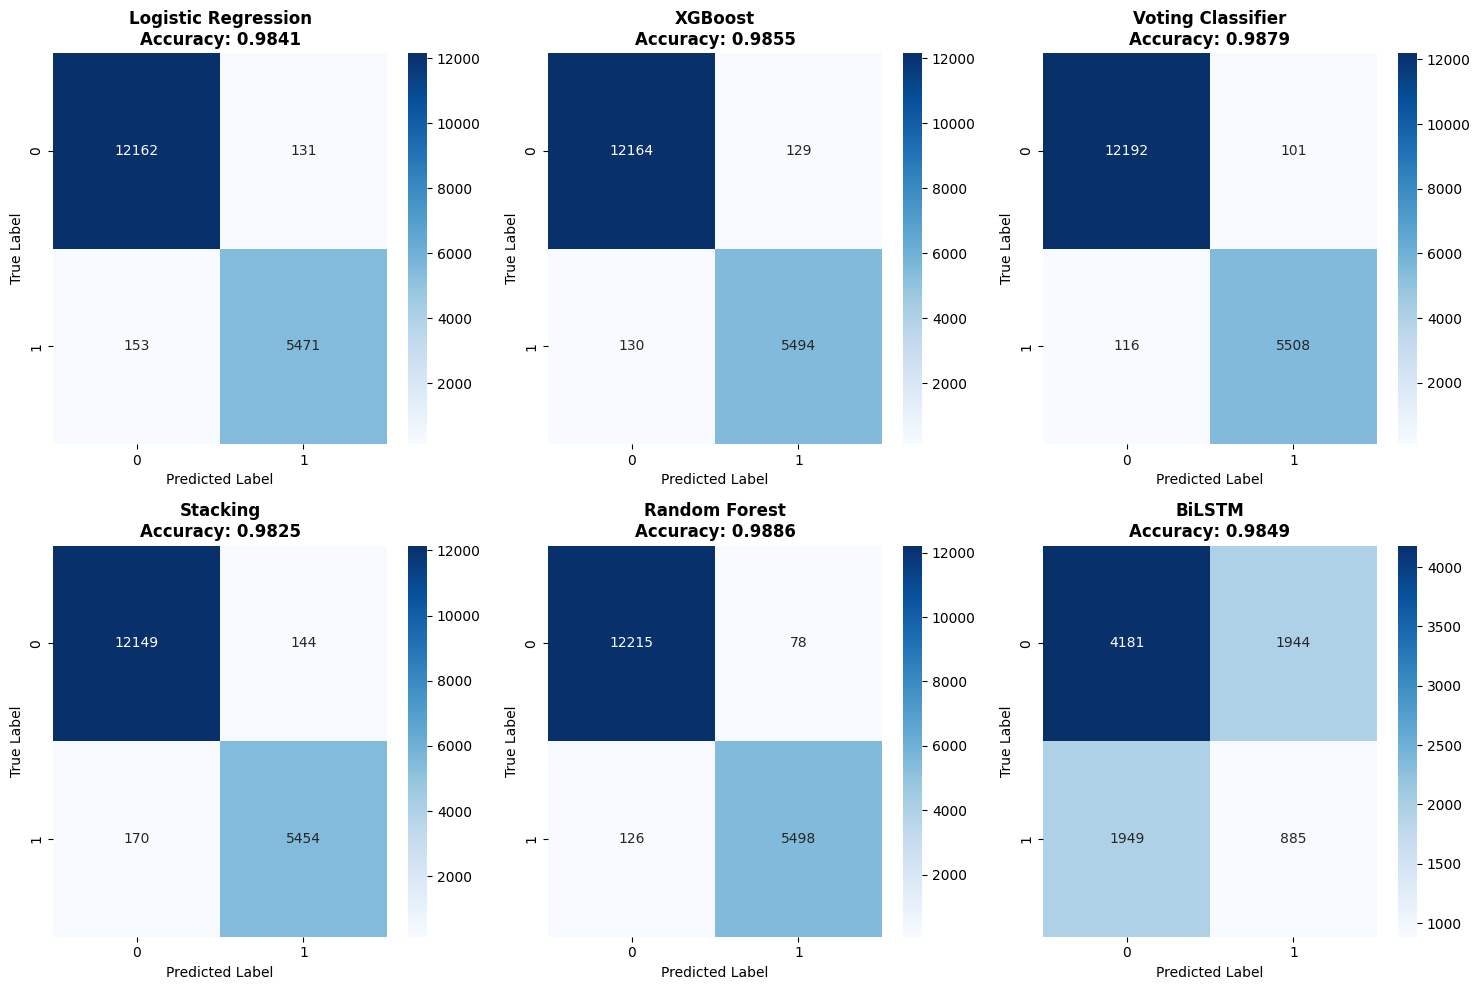

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

n_models = len(all_results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (model_name, results) in enumerate(all_results.items()):
    print(f"Model: {model_name}")
    print(f"y_test shape: {len(y_test)}, predictions shape: {len(results['predictions'])}")

    min_len = min(len(y_test), len(results['predictions']))
    y_test_subset = y_test[:min_len]
    pred_subset = results['predictions'][:min_len]

    cm = confusion_matrix(y_test_subset, pred_subset)

    unique_labels = sorted(list(set(y_test_subset) | set(pred_subset)))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx], cbar=True,
                xticklabels=unique_labels,
                yticklabels=unique_labels)

    axes[idx].set_title(f'{model_name}\nAccuracy: {results["accuracy"]:.4f}',
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

<h4> Compare Models </h4>

In [ ]:
comparison_data = []

for model_name, results in all_results.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1']
    })

comparison_df = pd.DataFrame(comparison_data)

comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

comparison_df.insert(0, 'Rank', range(1, len(comparison_df) + 1))

print("\n" + "="*90)
print(" "*30 + "MODEL PERFORMANCE COMPARISON")
print("="*90)
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print("="*90)

best_model_name = comparison_df.iloc[0]['Model']
best_f1_score = comparison_df.iloc[0]['F1-Score']

print(f"\n BEST MODEL: {best_model_name}")
print(f"   F1-Score: {best_f1_score:.4f}")
print("="*90)


                              MODEL PERFORMANCE COMPARISON
 Rank               Model  Accuracy  Precision  Recall  F1-Score
    1       Random Forest    0.9886     0.9886  0.9886    0.9886
    2   Voting Classifier    0.9879     0.9879  0.9879    0.9879
    3             XGBoost    0.9855     0.9855  0.9855    0.9855
    4              BiLSTM    0.9849     0.9849  0.9849    0.9849
    5 Logistic Regression    0.9841     0.9841  0.9841    0.9841
    6            Stacking    0.9825     0.9825  0.9825    0.9825

 BEST MODEL: Random Forest
   F1-Score: 0.9886


<center> Model Validation with Explainable AI (XAI) </center>

---


In [ ]:
!pip install shap lime
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
import warnings

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d5f0e90de6c28ddd18f2fd942c01936e98bc0373f334cdd014f79eace0c70c3b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


<h4> Prepare Feature Names and Sample Data </h4>

In [ ]:
def create_feature_names(vectorizer, text_features_df):
    feature_names = []

    if hasattr(vectorizer, 'get_feature_names_out'):
        vocab_features = vectorizer.get_feature_names_out().tolist()
        feature_names.extend([f"word_{word}" for word in vocab_features])

    text_meta_features = text_features_df.columns.tolist()
    feature_names.extend([f"meta_{feat}" for feat in text_meta_features])

    feature_names.extend(['has_url', 'has_email', 'has_phone'])

    return feature_names

if 'Method 5' in best_method_name:  # TF-IDF+TF-IDF N-gram
    base_vectorizer = tfidf_vectorizer
elif 'Method 3' in best_method_name:  # TF-IDF N-gram
    base_vectorizer = tfidf_ngram_vectorizer
elif 'Method 1' in best_method_name:  # TF-IDF
    base_vectorizer = tfidf_vectorizer
elif 'Method 4' in best_method_name:  # TF-IDF+Count
    base_vectorizer = tfidf_vectorizer
else:
    base_vectorizer = count_vectorizer

feature_names = create_feature_names(base_vectorizer, text_features_df)

print(f"Total features: {len(feature_names)}")
print(f"Sample feature names: {feature_names[:5]}")
print(f"Text metadata features: {[f for f in feature_names if 'meta_' in f]}")
print(f"Binary features: {[f for f in feature_names if 'has_' in f]}")

# Select subset of test data for XAI
n_samples_xai = min(200, X_test.shape[0])
np.random.seed(42)
xai_indices = np.random.choice(X_test.shape[0], n_samples_xai, replace=False)

X_test_xai = X_test[xai_indices]
y_test_xai = y_test[xai_indices]

print(f"\nXAI analysis on {n_samples_xai} test samples")
print(f"Ham samples: {np.sum(y_test_xai == 0)}")
print(f"Smishing samples: {np.sum(y_test_xai == 1)}")

Total features: 5019
Sample feature names: ['word_020603', 'word_020903', 'word_0443', 'word_071104', 'word_07xx']
Text metadata features: ['meta_char_count', 'meta_word_count', 'meta_avg_word_length', 'meta_sentence_count', 'meta_uppercase_ratio', 'meta_uppercase_word_count', 'meta_exclamation_count', 'meta_question_count', 'meta_dollar_count', 'meta_special_char_count', 'meta_digit_ratio', 'meta_urgency_word_count', 'meta_suspicious_word_count', 'meta_repeated_punctuation', 'meta_excessive_caps', 'meta_lexical_density']
Binary features: ['has_url', 'has_email', 'has_phone']

XAI analysis on 200 test samples
Ham samples: 148
Smishing samples: 52


<h4> SHAP - ML</h4>


Analyzing: Logistic Regression
Using LinearExplainer for Logistic Regression
SHAP values computed successfully
  Final shape: (200, 10019)

--- Global Feature Importance for Logistic Regression ---
  SHAP value range: [0.000000, 2.422302]
  Non-zero features: 1765/10019

Top 15 Most Important Features:
   1. meta_char_count                         : 2.422302
   2. meta_sentence_count                     : 0.883113
   3. meta_suspicious_word_count              : 0.826370
   4. has_url                                 : 0.619974
   5. meta_special_char_count                 : 0.603498
   6. count_word_haha                         : 0.519956
   7. meta_word_count                         : 0.428889
   8. meta_lexical_density                    : 0.382971
   9. count_word_offer                        : 0.275491
  10. meta_digit_ratio                        : 0.217883
  11. count_word_call                         : 0.196548
  12. count_word_reply                        : 0.178665
  13. meta_

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/tmp/ipykernel_2876/935822953.py:155: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


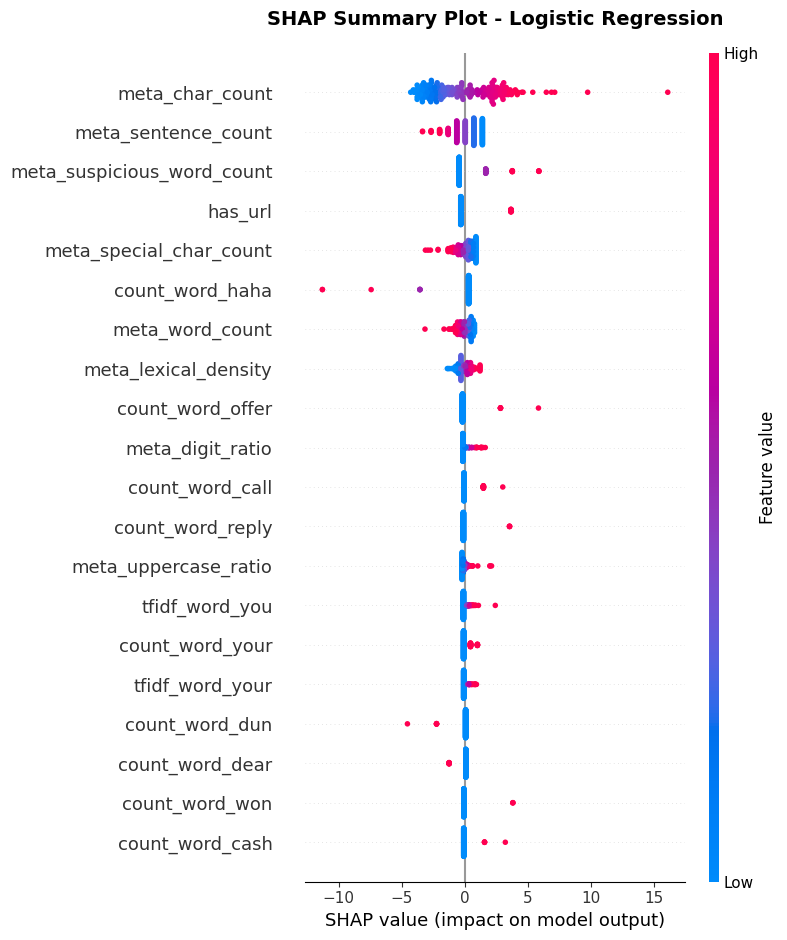


Generating bar plot...


/tmp/ipykernel_2876/935822953.py:168: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


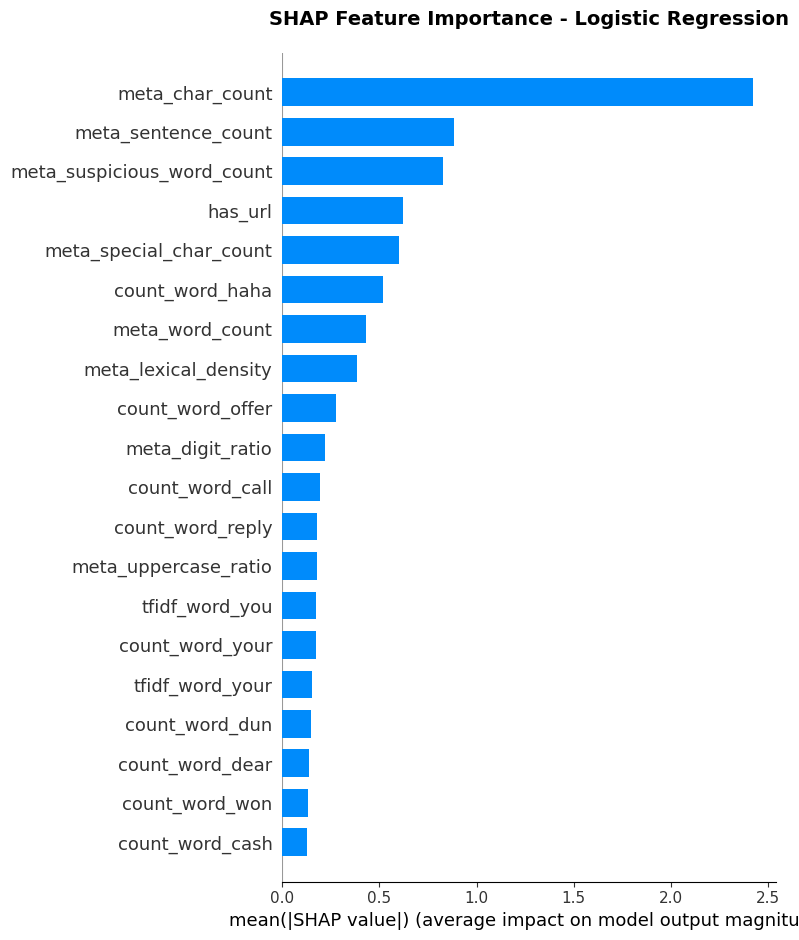


Analyzing: XGBoost
Using TreeExplainer for XGBoost with workaround
SHAP values computed successfully
  Final shape: (200, 10019)

--- Global Feature Importance for XGBoost ---
  SHAP value range: [0.000000, 1.872579]
  Non-zero features: 400/10019

Top 15 Most Important Features:
   1. meta_char_count                         : 1.872579
   2. meta_avg_word_length                    : 0.643907
   3. meta_digit_ratio                        : 0.604156
   4. meta_suspicious_word_count              : 0.576778
   5. meta_uppercase_ratio                    : 0.551147
   6. meta_special_char_count                 : 0.496020
   7. has_url                                 : 0.441476
   8. meta_sentence_count                     : 0.388715
   9. tfidf_word_your                         : 0.357764
  10. tfidf_word_call                         : 0.214047
  11. meta_lexical_density                    : 0.175322
  12. meta_uppercase_word_count               : 0.148490
  13. tfidf_word_you              

/tmp/ipykernel_2876/935822953.py:155: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


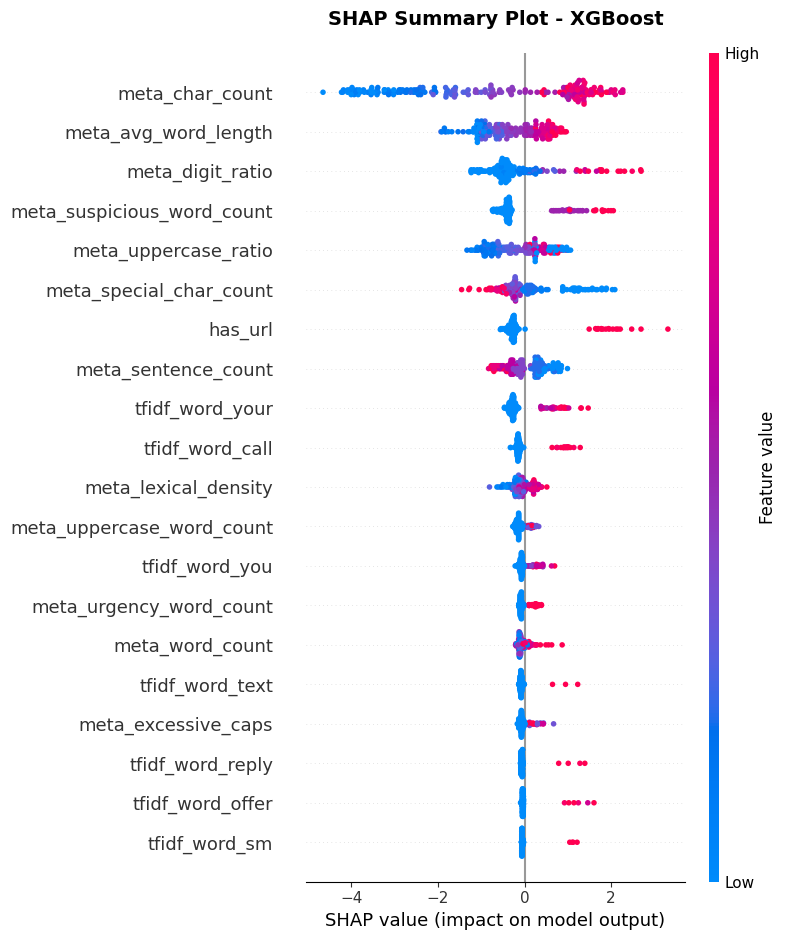


Generating bar plot...


/tmp/ipykernel_2876/935822953.py:168: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


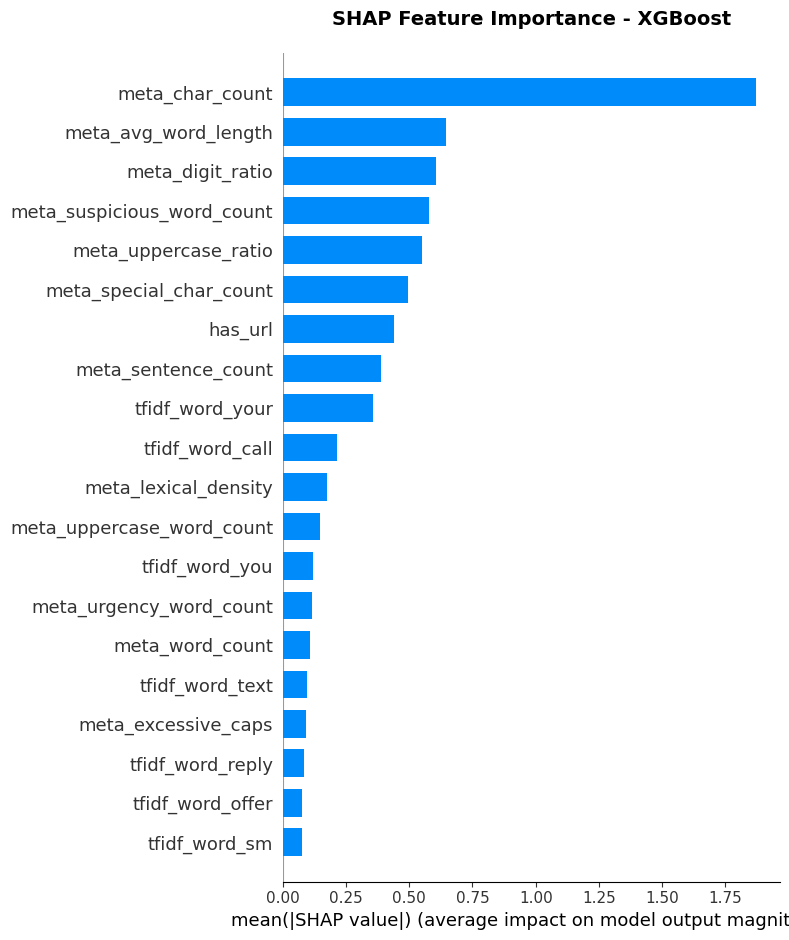

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import json

shap_results = {}

tree_models = ['XGBoost', 'Random Forest']
linear_models = ['Logistic Regression']

for model_name, model_info in ml_results.items():
    if model_name == 'Naive Bayes':
        continue

    print(f"\n{'='*80}")
    print(f"Analyzing: {model_name}")
    print(f"{'='*80}")

    model = model_info['model']

    try:
        if model_name == 'XGBoost':
            print(f"Using TreeExplainer for {model_name} with workaround")

            model_json = model.get_booster().save_config()
            config = json.loads(model_json)

            if 'learner' in config and 'learner_model_param' in config['learner']:
                base_score_str = config['learner']['learner_model_param'].get('base_score', '0.5')

                base_score_str = base_score_str.strip().strip('[]')

                config['learner']['learner_model_param']['base_score'] = base_score_str
                model.get_booster().load_config(json.dumps(config))

            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_xai)

        elif model_name == 'Random Forest':
            print(f"Using TreeExplainer for {model_name}")
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_xai)

        elif model_name in linear_models:
            print(f"Using LinearExplainer for {model_name}")
            explainer = shap.LinearExplainer(model, X_test_xai, feature_perturbation="interventional")
            shap_values = explainer.shap_values(X_test_xai)

        else:
            print(f"Using KernelExplainer for {model_name} (this may take a while...)")
            n_background = min(100, int(0.1 * X_test_xai.shape[0]))
            background = shap.sample(X_test_xai, n_background)

            if hasattr(model, 'predict_proba'):
                predict_fn = lambda x: model.predict_proba(x)[:, 1]
            else:
                predict_fn = lambda x: model.predict(x)

            explainer = shap.KernelExplainer(predict_fn, background)

            n_explain = min(100, X_test_xai.shape[0])
            print(f"  Explaining {n_explain} samples (this may take a few minutes)...")
            shap_values = explainer.shap_values(X_test_xai[:n_explain])

        if isinstance(shap_values, list):
            if len(shap_values) == 2:
                shap_vals = shap_values[1]
            else:
                shap_vals = shap_values[0]
        else:
            if len(shap_values.shape) == 3:
                shap_vals = shap_values
                print(f"  3D SHAP values detected: {shap_values.shape}")

                if shap_values.shape[2] == 3:
                    shap_vals = shap_values[:, :, 1]
                    print("  Using class 1 (index 1) from 3D SHAP values")
                else:
                    shap_vals = shap_values[:, :, 0]
                    print("  Using first class (index 0) from 3D SHAP values")
            else:
                shap_vals = shap_values

        if len(shap_vals.shape) == 1:
            shap_vals = shap_vals.reshape(1, -1)
        elif len(shap_vals.shape) > 2:
            shap_vals = shap_vals.reshape(shap_vals.shape[0], -1)

        shap_results[model_name] = {
            'explainer': explainer,
            'shap_values': shap_vals,
            'base_value': explainer.expected_value if hasattr(explainer, 'expected_value') else None
        }

        print(f"SHAP values computed successfully")
        print(f"  Final shape: {shap_vals.shape}")

        print(f"\n--- Global Feature Importance for {model_name} ---")

        mean_abs_shap = np.abs(shap_vals).mean(axis=0)

        print(f"  SHAP value range: [{mean_abs_shap.min():.6f}, {mean_abs_shap.max():.6f}]")
        print(f"  Non-zero features: {np.sum(mean_abs_shap > 0)}/{len(mean_abs_shap)}")

        max_features = min(len(mean_abs_shap), X_final.shape[1])

        top_indices = np.argsort(mean_abs_shap)[:max_features][-15:][::-1]

        all_readable_names = []
        if 'Method 1' in best_method_name:
            all_readable_names.extend([f"tfidf_word_{w}" for w in tfidf_vectorizer.get_feature_names_out()])
        elif 'Method 2' in best_method_name:
            all_readable_names.extend([f"count_word_{w}" for w in count_vectorizer.get_feature_names_out()])
        elif 'Method 3' in best_method_name:
            all_readable_names.extend([f"ngram_{w}" for w in tfidf_ngram_vectorizer.get_feature_names_out()])
        elif 'Method 4' in best_method_name:
            all_readable_names.extend([f"tfidf_word_{w}" for w in tfidf_vectorizer.get_feature_names_out()])
            all_readable_names.extend([f"count_word_{w}" for w in count_vectorizer.get_feature_names_out()])
        elif 'Method 5' in best_method_name:
            all_readable_names.extend([f"tfidf_word_{w}" for w in tfidf_vectorizer.get_feature_names_out()])
            all_readable_names.extend([f"ngram_{w}" for w in tfidf_ngram_vectorizer.get_feature_names_out()])
        elif 'Method 6' in best_method_name:
            all_readable_names.extend([f"count_word_{w}" for w in count_vectorizer.get_feature_names_out()])
            all_readable_names.extend([f"ngram_{w}" for w in tfidf_ngram_vectorizer.get_feature_names_out()])
        else:
            all_readable_names.extend([f"word_{w}" for w in base_vectorizer.get_feature_names_out()])

        all_readable_names.extend([f"meta_{feat}" for feat in text_features_df.columns])
        all_readable_names.extend(['has_url', 'has_email', 'has_phone'])

        def get_readable_feature_name(idx):
            if idx < len(all_readable_names):
                return all_readable_names[idx]
            return f"feature_{idx}"

        top_features = [get_readable_feature_name(i) for i in top_indices]
        top_values = mean_abs_shap[top_indices]

        print("\nTop 15 Most Important Features:")
        for i, (feat, val) in enumerate(zip(top_features, top_values), 1):
            print(f"  {i:2d}. {feat:40s}: {val:.6f}")

        print(f"\nGenerating summary plot...")
        plt.figure(figsize=(12, 8))

        top_n = min(20, len(mean_abs_shap))
        top_feature_indices = np.argsort(mean_abs_shap)[:len(mean_abs_shap)][-top_n:][::-1]

        X_display = X_test_xai[:, top_feature_indices]
        if hasattr(X_display, 'toarray'):
            X_display = X_display.toarray()
        shap_display = shap_vals[:, top_feature_indices]
        feature_names_display = [get_readable_feature_name(i) for i in top_feature_indices]

        shap.summary_plot(
            shap_display,
            X_display,
            feature_names=feature_names_display,
            show=False,
            max_display=top_n
        )
        plt.title(f'SHAP Summary Plot - {model_name}', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

        print(f"\nGenerating bar plot...")
        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            shap_display,
            X_display,
            feature_names=feature_names_display,
            plot_type="bar",
            show=False,
            max_display=top_n
        )
        plt.title(f'SHAP Feature Importance - {model_name}', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error analyzing {model_name}: {str(e)}")
        print(f"  Skipping to next model...")
        import traceback
        traceback.print_exc()
        continue

<h4> SHAP - EL</h4>


Analyzing: Voting Classifier
Using KernelExplainer with sampling for Voting Classifier
Computing SHAP values for 50 samples...


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=1.396e-01, with an active set of 2 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=6.998e-02, with an active set of 6 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=6.998e-02, with an active set of 6 regressors, and the smallest cholesky pivot element being 2

SHAP values computed successfully

--- Global Feature Importance for Voting Classifier ---

Top 15 Most Important Features:
   1. meta_char_count                         : 0.0426
   2. has_url                                 : 0.0185
   3. tfidf_word_draw                         : 0.0137
   4. meta_suspicious_word_count              : 0.0112
   5. count_word_drdesc                       : 0.0110
   6. tfidf_word_box                          : 0.0091
   7. tfidf_word_data                         : 0.0084
   8. count_word_better                       : 0.0080
   9. tfidf_word_thanks                       : 0.0070
  10. tfidf_word_end                          : 0.0070
  11. count_word_shall                        : 0.0066
  12. meta_digit_ratio                        : 0.0063
  13. count_word_finish                       : 0.0061
  14. count_word_end                          : 0.0058
  15. count_word_hasnt                        : 0.0049

Generating summary plot...


/tmp/ipykernel_2876/3121274580.py:96: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


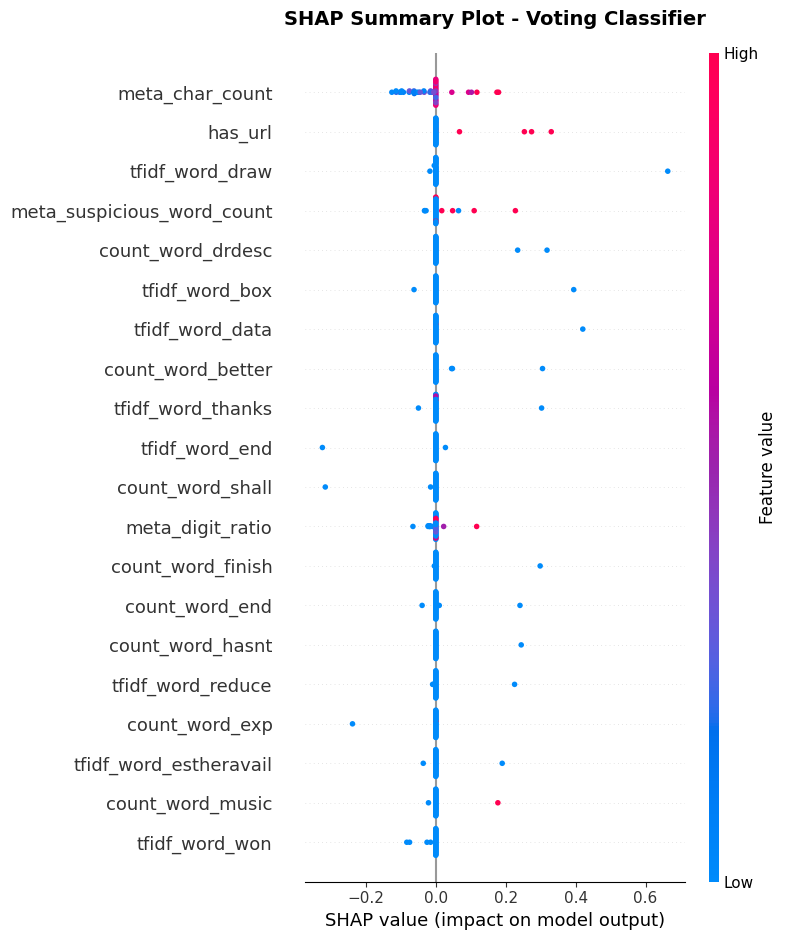

/tmp/ipykernel_2876/3121274580.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


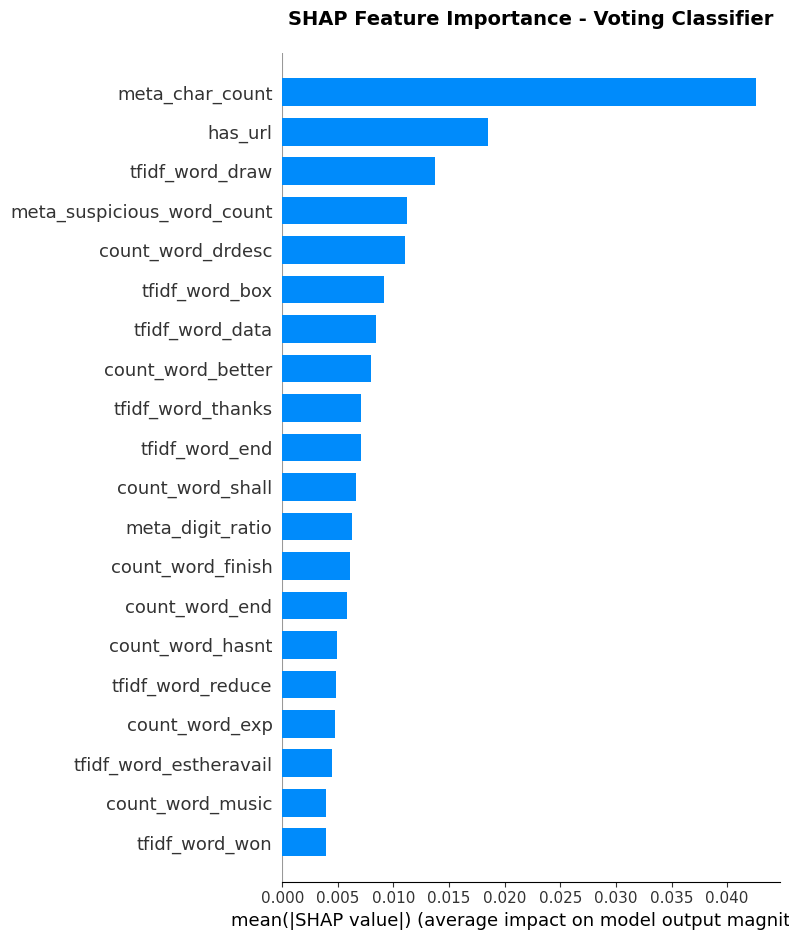


Analyzing: Stacking
Using KernelExplainer with sampling for Stacking
Computing SHAP values for 50 samples...


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=8.860e-02, with an active set of 5 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=3.185e-02, with an active set of 8 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up

SHAP values computed successfully

--- Global Feature Importance for Stacking ---

Top 15 Most Important Features:
   1. meta_char_count                         : 0.0537
   2. has_url                                 : 0.0144
   3. tfidf_word_hee                          : 0.0103
   4. tfidf_word_due                          : 0.0100
   5. tfidf_word_back                         : 0.0100
   6. tfidf_word_kyc                          : 0.0094
   7. tfidf_word_askmegrocery                 : 0.0089
   8. tfidf_word_also                         : 0.0084
   9. tfidf_word_pas                          : 0.0078
  10. tfidf_word_dessert                      : 0.0076
  11. tfidf_word_philosophy                   : 0.0076
  12. tfidf_word_time                         : 0.0075
  13. tfidf_word_inr200                       : 0.0071
  14. tfidf_word_activity                     : 0.0064
  15. meta_digit_ratio                        : 0.0064

Generating summary plot...


/tmp/ipykernel_2876/3121274580.py:96: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


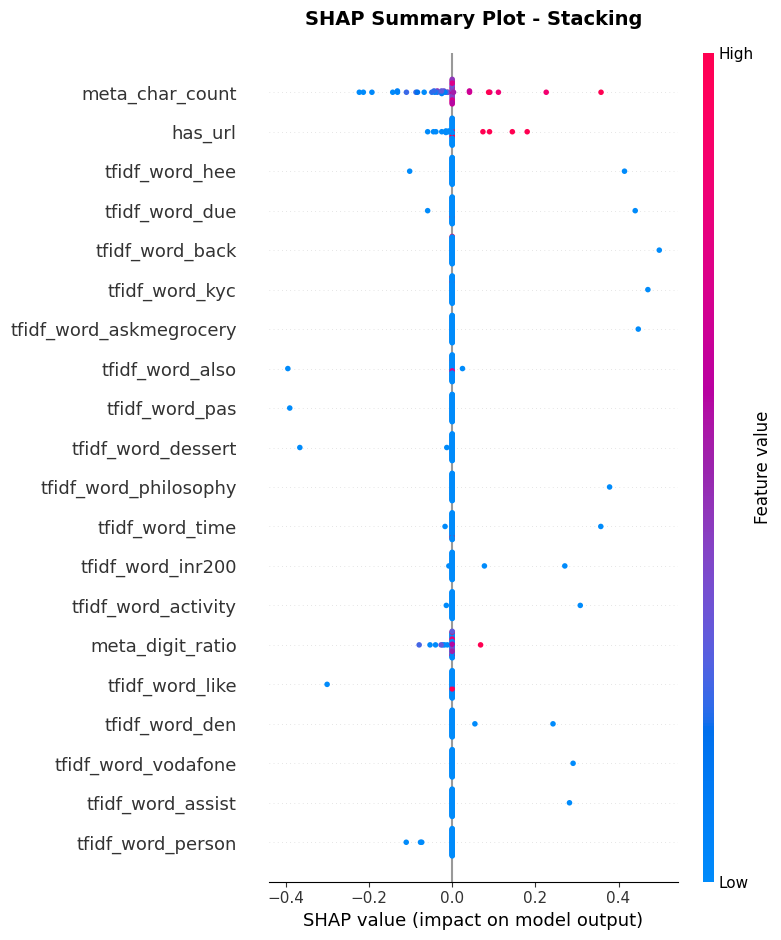

/tmp/ipykernel_2876/3121274580.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


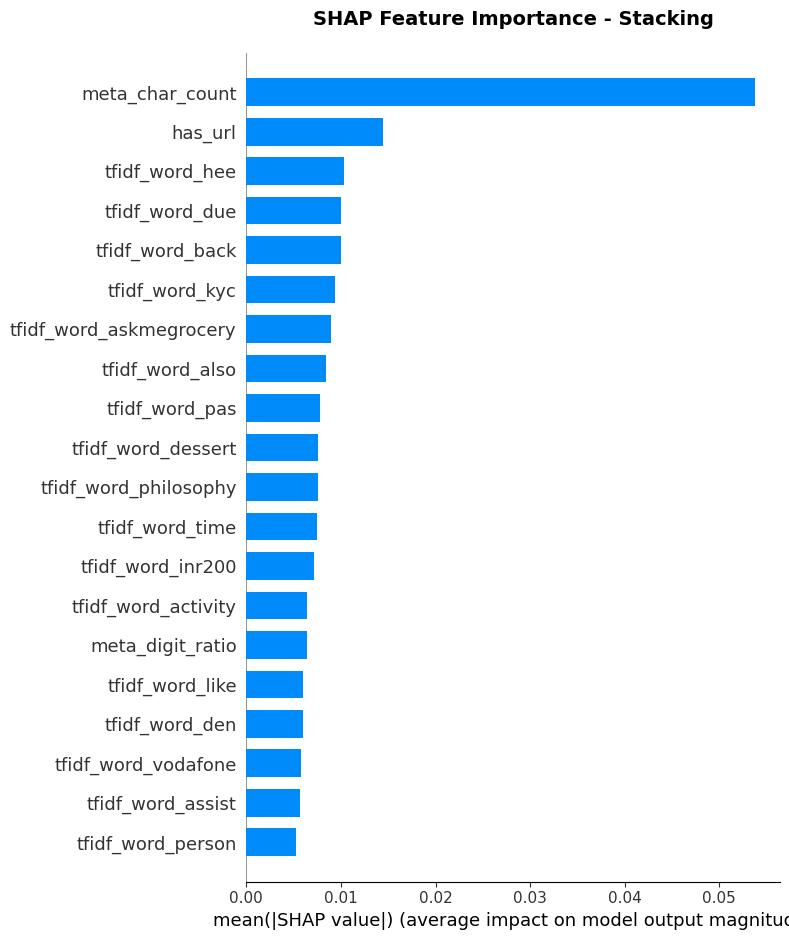


Analyzing: Random Forest
Using KernelExplainer with sampling for Random Forest
Computing SHAP values for 50 samples...


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=1.304e-01, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=6.675e-02, with an active set of 8 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=3.979e-02, with an active set of 3 regressors, and the smallest cholesky pivot element being 2

SHAP values computed successfully

--- Global Feature Importance for Random Forest ---

Top 15 Most Important Features:
   1. meta_char_count                         : 0.0130
   2. has_url                                 : 0.0097
   3. count_word_your                         : 0.0093
   4. tfidf_word_vodafone                     : 0.0079
   5. tfidf_word_good                         : 0.0069
   6. tfidf_word_dad                          : 0.0066
   7. tfidf_word_start                        : 0.0060
   8. meta_word_count                         : 0.0060
   9. meta_special_char_count                 : 0.0054
  10. tfidf_word_payment                      : 0.0053
  11. tfidf_word_credit                       : 0.0051
  12. count_word_one                          : 0.0050
  13. tfidf_word_control                      : 0.0050
  14. count_word_immediately                  : 0.0049
  15. count_word_vodafone                     : 0.0046

Generating summary plot...


/tmp/ipykernel_2876/3121274580.py:96: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


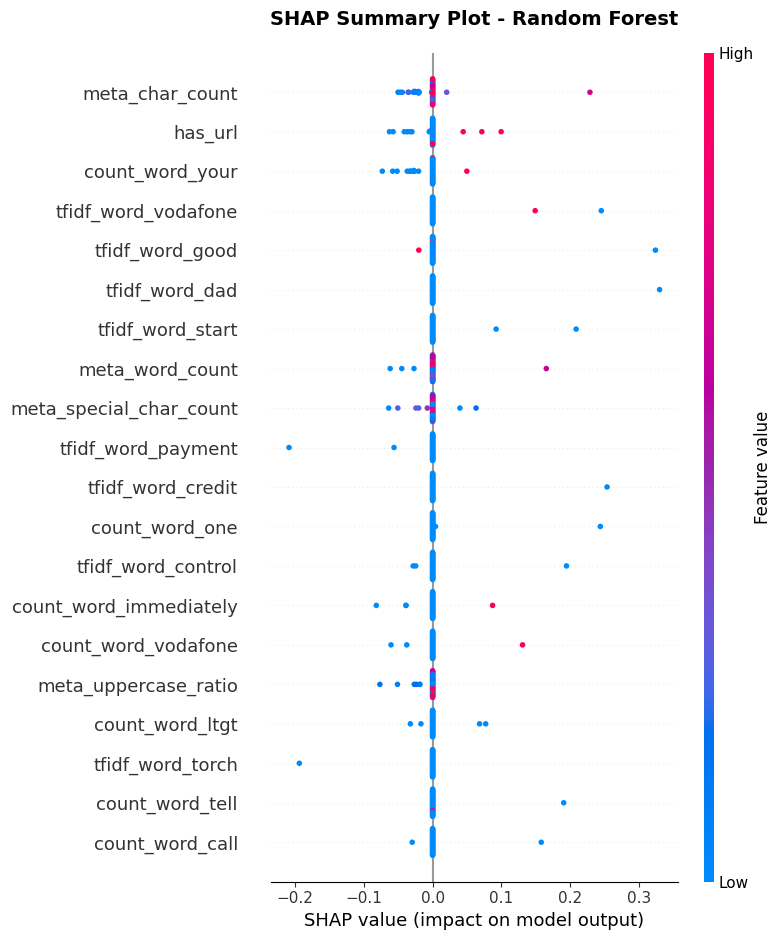

/tmp/ipykernel_2876/3121274580.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


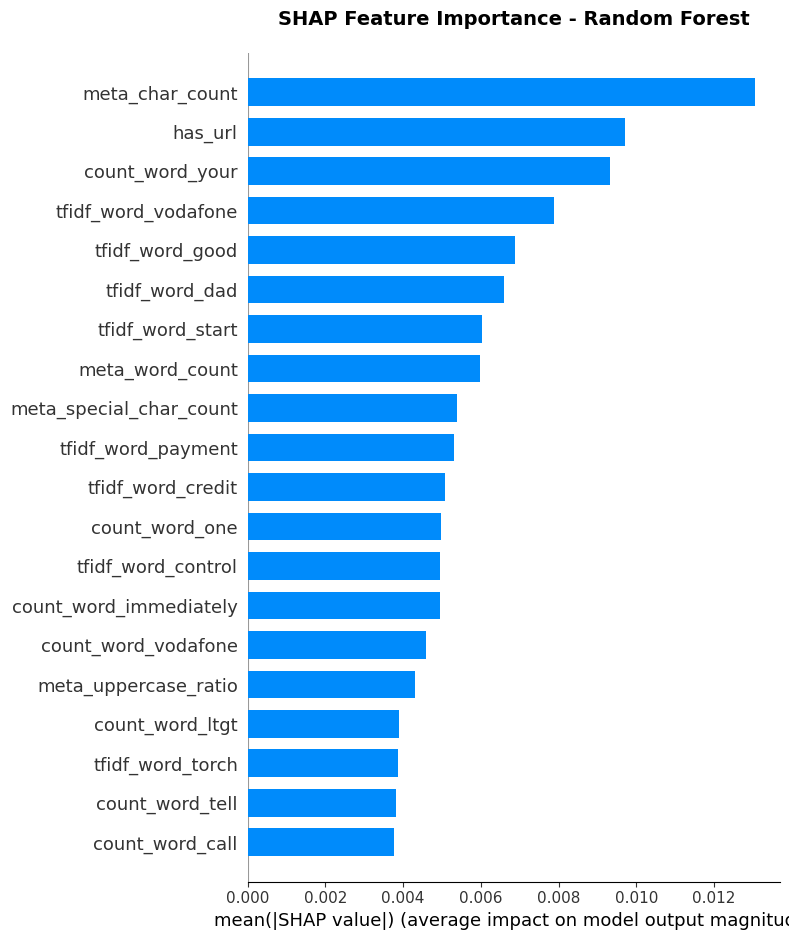

In [ ]:
for model_name, model_info in ensemble_results.items():
    print(f"\n{'='*80}")
    print(f"Analyzing: {model_name}")
    print(f"{'='*80}")

    model = model_info['model']

    try:
        print(f"Using KernelExplainer with sampling for {model_name}")

        n_samples = X_test_xai.shape[0]

        background_size = min(50, n_samples)
        background_indices = np.random.choice(n_samples, background_size, replace=False)
        X_background = X_test_xai[background_indices]

        if hasattr(X_background, 'toarray'):
            X_background = X_background.toarray()

        def model_predict(X):
            if hasattr(X, 'toarray'):
                return model.predict_proba(X)[:, 1]
            else:
                from scipy.sparse import csr_matrix
                X_sparse = csr_matrix(X)
                return model.predict_proba(X_sparse)[:, 1]

        explainer = shap.KernelExplainer(model_predict, X_background)

        n_explain = min(50, n_samples)
        X_explain = X_test_xai[:n_explain]
        if hasattr(X_explain, 'toarray'):
            X_explain = X_explain.toarray()

        print(f"Computing SHAP values for {n_explain} samples...")
        shap_values = explainer.shap_values(X_explain, nsamples=100)

        shap_results[model_name] = {
            'explainer': explainer,
            'shap_values': shap_values,
            'base_value': explainer.expected_value
        }

        print(f"SHAP values computed successfully")

        print(f"\n--- Global Feature Importance for {model_name} ---")

        mean_abs_shap = np.abs(shap_values).mean(axis=0)

        top_indices = np.argsort(mean_abs_shap)[-15:][::-1]

        all_readable_names = []
        if 'Method 1' in best_method_name:
            all_readable_names.extend([f"tfidf_word_{w}" for w in tfidf_vectorizer.get_feature_names_out()])
        elif 'Method 2' in best_method_name:
            all_readable_names.extend([f"count_word_{w}" for w in count_vectorizer.get_feature_names_out()])
        elif 'Method 3' in best_method_name:
            all_readable_names.extend([f"ngram_{w}" for w in tfidf_ngram_vectorizer.get_feature_names_out()])
        elif 'Method 4' in best_method_name:
            all_readable_names.extend([f"tfidf_word_{w}" for w in tfidf_vectorizer.get_feature_names_out()])
            all_readable_names.extend([f"count_word_{w}" for w in count_vectorizer.get_feature_names_out()])
        elif 'Method 5' in best_method_name:
            all_readable_names.extend([f"tfidf_word_{w}" for w in tfidf_vectorizer.get_feature_names_out()])
            all_readable_names.extend([f"ngram_{w}" for w in tfidf_ngram_vectorizer.get_feature_names_out()])
        elif 'Method 6' in best_method_name:
            all_readable_names.extend([f"count_word_{w}" for w in count_vectorizer.get_feature_names_out()])
            all_readable_names.extend([f"ngram_{w}" for w in tfidf_ngram_vectorizer.get_feature_names_out()])
        else:
            all_readable_names.extend([f"word_{w}" for w in base_vectorizer.get_feature_names_out()])

        all_readable_names.extend([f"meta_{feat}" for feat in text_features_df.columns])
        all_readable_names.extend(['has_url', 'has_email', 'has_phone'])

        def get_readable_feature_name(idx):
            if idx < len(all_readable_names):
                return all_readable_names[idx]
            return f"feature_{idx}"

        top_features = [get_readable_feature_name(i) for i in top_indices]
        top_values = mean_abs_shap[top_indices]

        print("\nTop 15 Most Important Features:")
        for i, (feat, val) in enumerate(zip(top_features, top_values), 1):
            print(f"  {i:2d}. {feat:40s}: {val:.4f}")

        print(f"\nGenerating summary plot...")
        plt.figure(figsize=(12, 8))

        top_n = 20
        top_feature_indices = np.argsort(mean_abs_shap)[-top_n:][::-1]

        shap_display = shap_values[:, top_feature_indices]
        X_display = X_explain[:, top_feature_indices]
        feature_names_display = [get_readable_feature_name(i) for i in top_feature_indices]

        shap.summary_plot(
            shap_display,
            X_display,
            feature_names=feature_names_display,
            show=False,
            max_display=20
        )
        plt.title(f'SHAP Summary Plot - {model_name}', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            shap_display,
            X_display,
            feature_names=feature_names_display,
            plot_type="bar",
            show=False,
            max_display=20
        )
        plt.title(f'SHAP Feature Importance - {model_name}', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error analyzing {model_name}: {str(e)}")
        print(f"  Skipping to next model...")
        import traceback
        traceback.print_exc()
        continue

<h4> LIME Setup</h4>

In [ ]:
all_readable_names = []
if 'Method 1' in best_method_name:
    all_readable_names.extend([f"tfidf_word_{w}" for w in tfidf_vectorizer.get_feature_names_out()])
elif 'Method 2' in best_method_name:
    all_readable_names.extend([f"count_word_{w}" for w in count_vectorizer.get_feature_names_out()])
elif 'Method 3' in best_method_name:
    all_readable_names.extend([f"ngram_{w}" for w in tfidf_ngram_vectorizer.get_feature_names_out()])
elif 'Method 4' in best_method_name:
    all_readable_names.extend([f"tfidf_word_{w}" for w in tfidf_vectorizer.get_feature_names_out()])
    all_readable_names.extend([f"count_word_{w}" for w in count_vectorizer.get_feature_names_out()])
elif 'Method 5' in best_method_name:
    all_readable_names.extend([f"tfidf_word_{w}" for w in tfidf_vectorizer.get_feature_names_out()])
    all_readable_names.extend([f"ngram_{w}" for w in tfidf_ngram_vectorizer.get_feature_names_out()])
elif 'Method 6' in best_method_name:
    all_readable_names.extend([f"count_word_{w}" for w in count_vectorizer.get_feature_names_out()])
    all_readable_names.extend([f"ngram_{w}" for w in tfidf_ngram_vectorizer.get_feature_names_out()])
else:
    all_readable_names.extend([f"word_{w}" for w in base_vectorizer.get_feature_names_out()])

all_readable_names.extend([f"meta_{feat}" for feat in text_features_df.columns])
all_readable_names.extend(['has_url', 'has_email', 'has_phone'])

def get_readable_feature_name(idx):
    if idx < len(all_readable_names):
        return all_readable_names[idx]
    return f"feature_{idx}"

X_test_dense = X_test_xai.toarray() if hasattr(X_test_xai, 'toarray') else X_test_xai
X_train_dense = X_train_final.toarray() if hasattr(X_train_final, 'toarray') else X_train_final

print(f"X_train_dense shape: {X_train_dense.shape}")
print(f"X_test_dense shape: {X_test_dense.shape}")
print(f"Feature names length: {len(feature_names)}")

readable_feature_names = [get_readable_feature_name(i) for i in range(X_train_dense.shape[1])]

lime_explainer = LimeTabularExplainer(
    training_data=X_train_dense[:500],
    feature_names=readable_feature_names,
    class_names=['Ham', 'Smishing'],
    mode='classification',
    random_state=42
)

print(f"LIME explainer created")
print(f"  Training samples used: 500")
print(f"  Feature names: {len(readable_feature_names)}")

X_train_dense shape: (71666, 10019)
X_test_dense shape: (200, 10019)
Feature names length: 5019
LIME explainer created
  Training samples used: 500
  Feature names: 10019


<h4> LIME All Models</h4>


Analyzing 5 random examples across all models

LIME Analysis: Logistic Regression

--- Example 1 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.998)

  Top 10 Contributing Features:
     1. count_word_came <= 0.00                      : +0.3572 → Smishing
     2. tfidf_word_youre <= 0.00                     : -0.3324 → Ham
     3. meta_char_count <= -0.82                     : -0.3289 → Ham
     4. count_word_hahaha <= 0.00                    : +0.3236 → Smishing
     5. count_word_link <= 0.00                      : -0.3040 → Ham
     6. count_word_app <= 0.00                       : +0.2720 → Smishing
     7. tfidf_word_angry <= 0.00                     : +0.2276 → Smishing
     8. has_url <= 0.00                              : -0.2184 → Ham
     9. tfidf_word_apply <= 0.00                     : -0.1942 → Ham
    10. tfidf_word_hostel <= 0.00                    : -0.1918 → Ham

  Generating visualization...


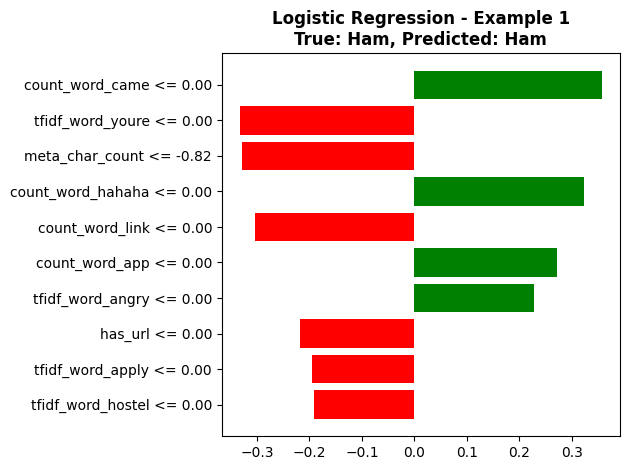


--- Example 2 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. tfidf_word_early <= 0.00                     : -0.3933 → Ham
     2. tfidf_word_tried <= 0.00                     : -0.3889 → Ham
     3. count_word_first <= 0.00                     : -0.3485 → Ham
     4. count_word_apply <= 0.00                     : -0.3362 → Ham
     5. tfidf_word_service <= 0.00                   : -0.3331 → Ham
     6. meta_char_count <= -0.82                     : -0.3104 → Ham
     7. count_word_starting <= 0.00                  : -0.3039 → Ham
     8. tfidf_word_buy <= 0.00                       : -0.2513 → Ham
     9. count_word_link <= 0.00                      : -0.2191 → Ham
    10. count_word_price <= 0.00                     : -0.1732 → Ham

  Generating visualization...


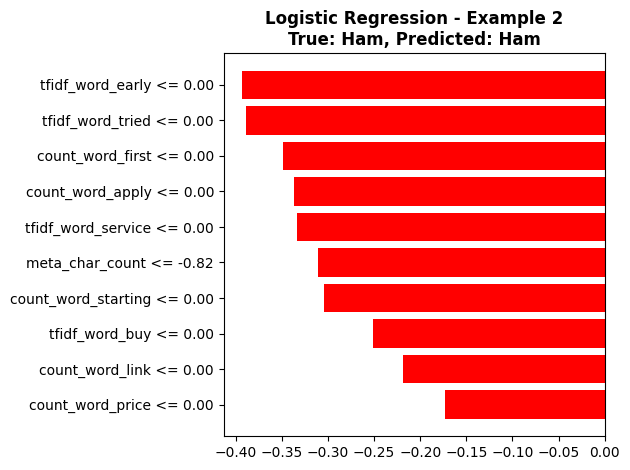


--- Example 3 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. count_word_receive <= 0.00                   : -0.4707 → Ham
     2. count_word_daddy <= 0.00                     : -0.4367 → Ham
     3. count_word_total <= 0.00                     : -0.4280 → Ham
     4. count_word_reply <= 0.00                     : -0.3521 → Ham
     5. meta_char_count <= -0.82                     : -0.3118 → Ham
     6. has_url <= 0.00                              : -0.3090 → Ham
     7. tfidf_word_item <= 0.00                      : +0.2302 → Smishing
     8. count_word_offer <= 0.00                     : -0.2194 → Ham
     9. tfidf_word_easy <= 0.00                      : +0.1956 → Smishing
    10. tfidf_word_jiayou <= 0.00                    : -0.1170 → Ham

  Generating visualization...


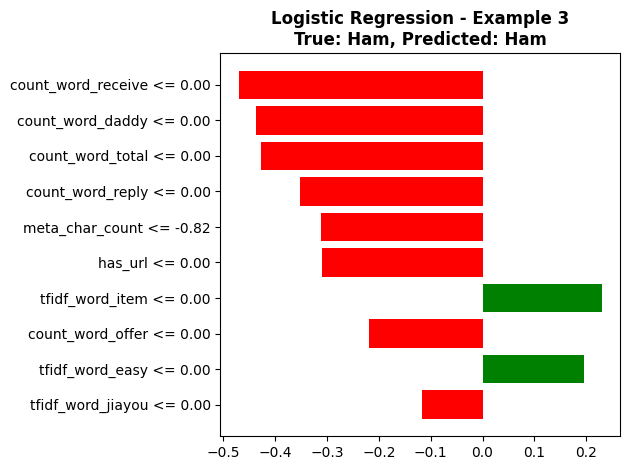


--- Example 4 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. count_word_reply <= 0.00                     : -0.5095 → Ham
     2. tfidf_word_monday <= 0.00                    : -0.4633 → Ham
     3. count_word_show <= 0.00                      : -0.3569 → Ham
     4. count_word_doorstep <= 0.00                  : -0.3381 → Ham
     5. tfidf_word_return <= 0.00                    : -0.3198 → Ham
     6. count_word_back <= 0.00                      : -0.2911 → Ham
     7. count_word_coming <= 0.00                    : +0.2664 → Smishing
     8. count_word_thank <= 0.00                     : -0.2258 → Ham
     9. has_url <= 0.00                              : -0.1770 → Ham
    10. tfidf_word_thank <= 0.00                     : -0.1664 → Ham

  Generating visualization...


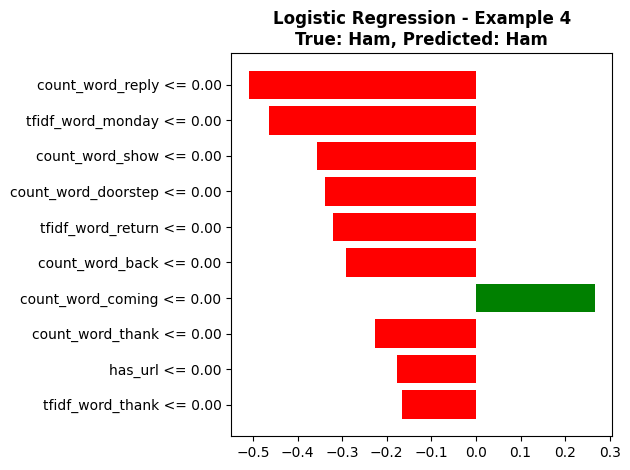


--- Example 5 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. count_word_link <= 0.00                      : -0.5690 → Ham
     2. tfidf_word_select <= 0.00                    : -0.4744 → Ham
     3. count_word_freefone <= 0.00                  : -0.4429 → Ham
     4. tfidf_word_soon <= 0.00                      : -0.3949 → Ham
     5. count_word_reply <= 0.00                     : -0.3489 → Ham
     6. count_word_bus <= 0.00                       : +0.3045 → Smishing
     7. count_word_day <= 0.00                       : -0.2311 → Ham
     8. count_word_price <= 0.00                     : +0.2136 → Smishing
     9. -0.82 < meta_char_count <= -0.35             : -0.2050 → Ham
    10. meta_suspicious_word_count <= -0.45          : -0.1941 → Ham

  Generating visualization...


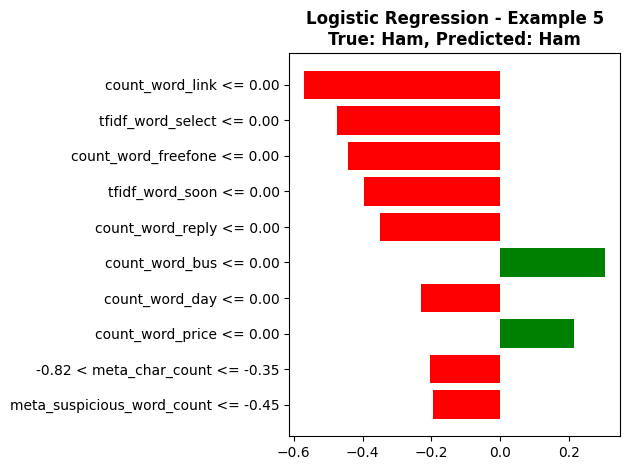


LIME analysis completed for Logistic Regression

LIME Analysis: XGBoost

--- Example 1 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.999)

  Top 10 Contributing Features:
     1. meta_char_count <= -0.82                     : -0.3798 → Ham
     2. tfidf_word_meeting <= 0.00                   : +0.3717 → Smishing
     3. tfidf_word_call <= 0.00                      : -0.2453 → Ham
     4. has_url <= 0.00                              : -0.2420 → Ham
     5. tfidf_word_ave <= 0.00                       : -0.1999 → Ham
     6. tfidf_word_link <= 0.00                      : -0.1891 → Ham
     7. tfidf_word_haha <= 0.00                      : +0.1878 → Smishing
     8. tfidf_word_click <= 0.00                     : -0.1828 → Ham
     9. count_word_app <= 0.00                       : -0.1780 → Ham
    10. tfidf_word_dial <= 0.00                      : -0.1665 → Ham

  Generating visualization...


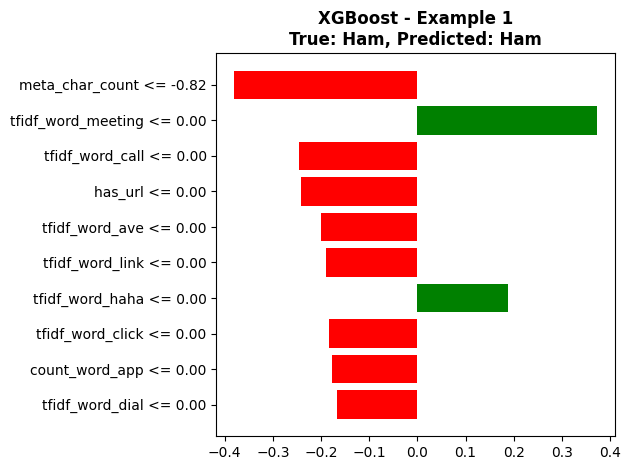


--- Example 2 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.999)

  Top 10 Contributing Features:
     1. count_word_bus <= 0.00                       : -0.3690 → Ham
     2. tfidf_word_text <= 0.00                      : -0.3628 → Ham
     3. count_word_sunday <= 0.00                    : +0.3242 → Smishing
     4. meta_char_count <= -0.82                     : -0.3221 → Ham
     5. tfidf_word_download <= 0.00                  : -0.3161 → Ham
     6. tfidf_word_lol <= 0.00                       : +0.2659 → Smishing
     7. has_url <= 0.00                              : -0.2162 → Ham
     8. tfidf_word_call <= 0.00                      : -0.2140 → Ham
     9. tfidf_word_your <= 0.00                      : -0.2015 → Ham
    10. tfidf_word_bonus <= 0.00                     : -0.1966 → Ham

  Generating visualization...


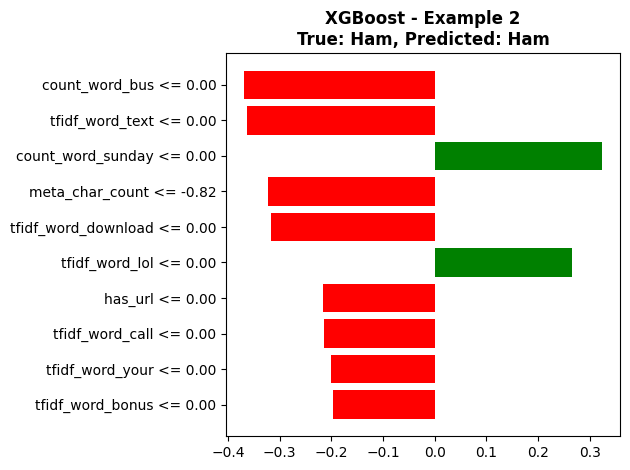


--- Example 3 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. meta_char_count <= -0.82                     : -0.3280 → Ham
     2. has_url <= 0.00                              : -0.3139 → Ham
     3. tfidf_word_open <= 0.00                      : -0.2862 → Ham
     4. count_word_stay <= 0.00                      : -0.2253 → Ham
     5. tfidf_word_call <= 0.00                      : -0.1978 → Ham
     6. tfidf_word_your <= 0.00                      : -0.1843 → Ham
     7. tfidf_word_common <= 0.00                    : +0.1831 → Smishing
     8. count_word_service <= 0.00                   : -0.1675 → Ham
     9. meta_digit_ratio <= -0.41                    : +0.1348 → Smishing
    10. tfidf_word_introducing <= 0.00               : +0.1283 → Smishing

  Generating visualization...


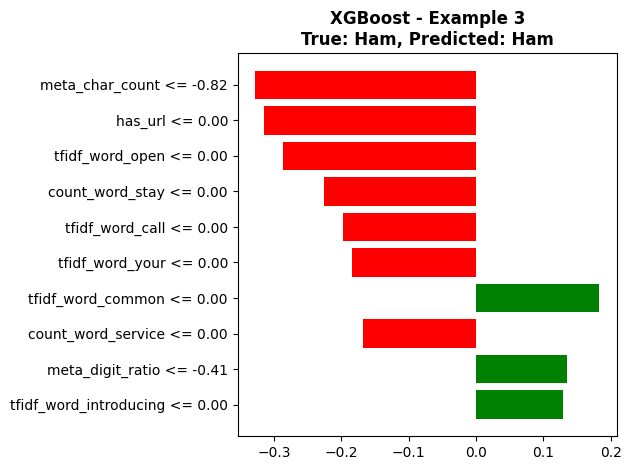


--- Example 4 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.992)

  Top 10 Contributing Features:
     1. count_word_already <= 0.00                   : -0.3722 → Ham
     2. has_url <= 0.00                              : -0.3576 → Ham
     3. tfidf_word_wat <= 0.00                       : -0.3414 → Ham
     4. tfidf_word_per <= 0.00                       : -0.3307 → Ham
     5. tfidf_word_user <= 0.00                      : -0.2917 → Ham
     6. tfidf_word_text <= 0.00                      : -0.2759 → Ham
     7. tfidf_word_call <= 0.00                      : -0.1958 → Ham
     8. tfidf_word_your <= 0.00                      : -0.1899 → Ham
     9. -0.35 < meta_char_count <= 0.61              : +0.1898 → Smishing
    10. count_word_valid <= 0.00                     : -0.1546 → Ham

  Generating visualization...


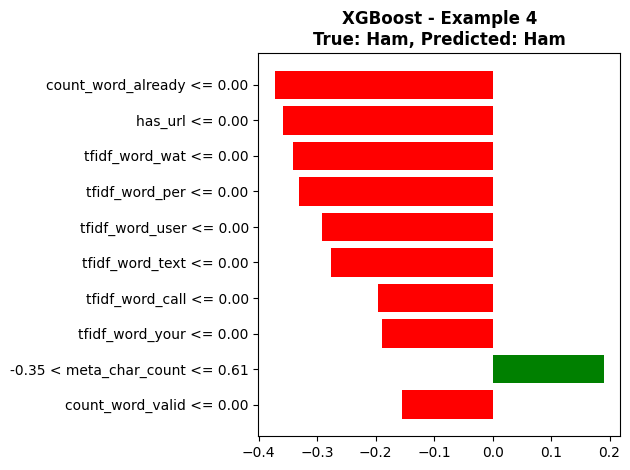


--- Example 5 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. count_word_weight <= 0.00                    : -0.3576 → Ham
     2. tfidf_word_failed <= 0.00                    : +0.2899 → Smishing
     3. tfidf_word_prize <= 0.00                     : -0.2610 → Ham
     4. count_word_wrk <= 0.00                       : +0.2425 → Smishing
     5. tfidf_word_claim <= 0.00                     : -0.2406 → Ham
     6. has_url <= 0.00                              : -0.2338 → Ham
     7. tfidf_word_call <= 0.00                      : -0.2209 → Ham
     8. count_word_price <= 0.00                     : +0.2179 → Smishing
     9. meta_avg_word_length <= -0.51                : -0.2072 → Ham
    10. tfidf_word_your <= 0.00                      : -0.1461 → Ham

  Generating visualization...


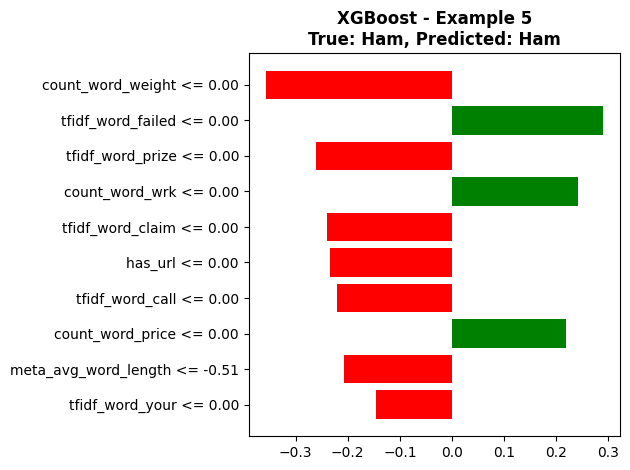


LIME analysis completed for XGBoost

LIME Analysis: Voting Classifier

--- Example 1 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.999)

  Top 10 Contributing Features:
     1. tfidf_word_there <= 0.00                     : +0.3103 → Smishing
     2. meta_char_count <= -0.82                     : -0.3056 → Ham
     3. tfidf_word_bonus <= 0.00                     : -0.2611 → Ham
     4. count_word_reply <= 0.00                     : -0.2352 → Ham
     5. has_url <= 0.00                              : -0.2126 → Ham
     6. count_word_thank <= 0.00                     : -0.2075 → Ham
     7. count_word_gift <= 0.00                      : -0.1836 → Ham
     8. count_word_time <= 0.00                      : +0.1720 → Smishing
     9. count_word_contact <= 0.00                   : -0.1342 → Ham
    10. meta_suspicious_word_count <= -0.45          : -0.1279 → Ham

  Generating visualization...


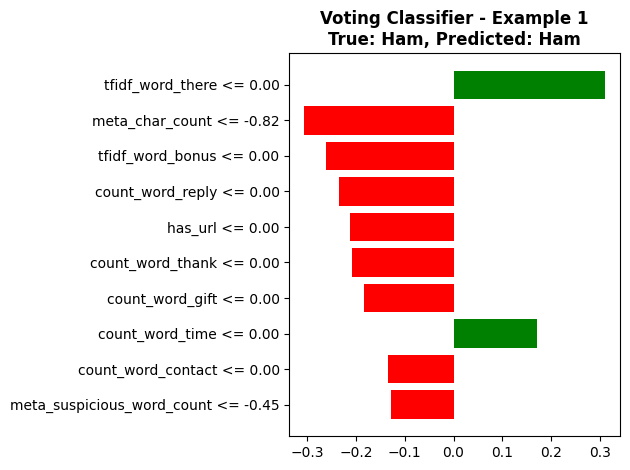


--- Example 2 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. count_word_full <= 0.00                      : -0.3665 → Ham
     2. count_word_pmin <= 0.00                      : -0.3577 → Ham
     3. meta_char_count <= -0.82                     : -0.3208 → Ham
     4. count_word_according <= 0.00                 : -0.3038 → Ham
     5. count_word_randomly <= 0.00                  : -0.2953 → Ham
     6. has_url <= 0.00                              : -0.2652 → Ham
     7. tfidf_word_immediately <= 0.00               : -0.2134 → Ham
     8. count_word_finish <= 0.00                    : +0.2102 → Smishing
     9. count_word_hurry <= 0.00                     : +0.1944 → Smishing
    10. tfidf_word_wat > 0.00                        : -0.1049 → Ham

  Generating visualization...


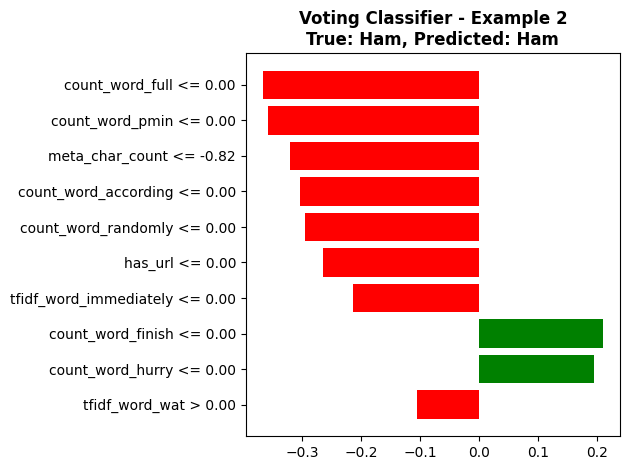


--- Example 3 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. count_word_work <= 0.00                      : -0.3073 → Ham
     2. meta_char_count <= -0.82                     : -0.3039 → Ham
     3. count_word_suspend <= 0.00                   : -0.2651 → Ham
     4. count_word_process <= 0.00                   : -0.2580 → Ham
     5. has_url <= 0.00                              : -0.2438 → Ham
     6. count_word_haha <= 0.00                      : +0.2054 → Smishing
     7. tfidf_word_your <= 0.00                      : -0.1312 → Ham
     8. tfidf_word_say <= 0.00                       : +0.1253 → Smishing
     9. count_word_claim <= 0.00                     : -0.1222 → Ham
    10. tfidf_word_way <= 0.00                       : +0.1157 → Smishing

  Generating visualization...


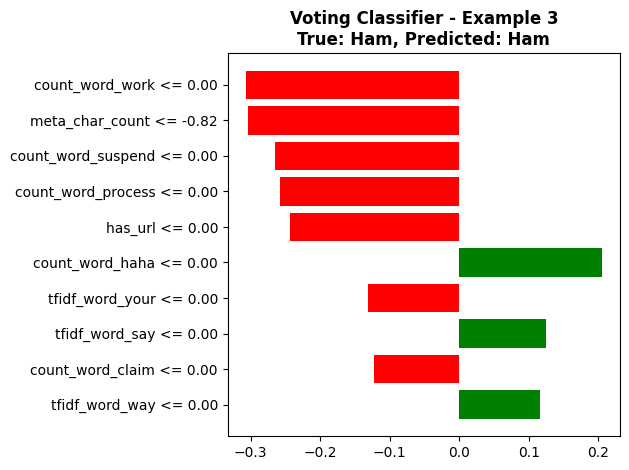


--- Example 4 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.996)

  Top 10 Contributing Features:
     1. tfidf_word_dad <= 0.00                       : -0.3573 → Ham
     2. tfidf_word_query <= 0.00                     : -0.3169 → Ham
     3. has_url <= 0.00                              : -0.2930 → Ham
     4. count_word_card <= 0.00                      : -0.2812 → Ham
     5. count_word_link <= 0.00                      : -0.2260 → Ham
     6. count_word_awarded <= 0.00                   : -0.2194 → Ham
     7. count_word_yesterday <= 0.00                 : -0.2183 → Ham
     8. tfidf_word_lol <= 0.00                       : +0.1859 → Smishing
     9. meta_suspicious_word_count <= -0.45          : -0.1492 → Ham
    10. count_word_haha <= 0.00                      : +0.1483 → Smishing

  Generating visualization...


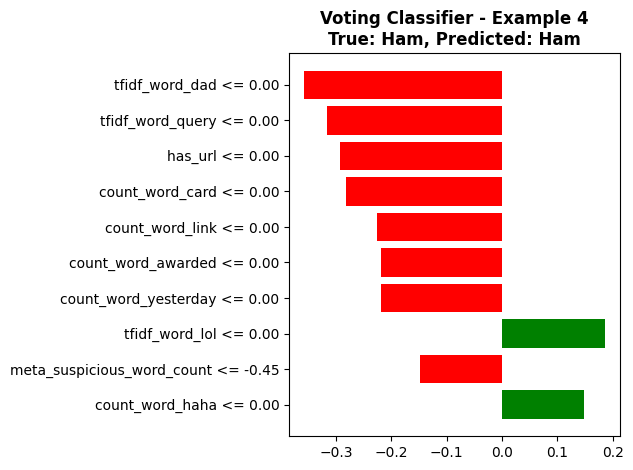


--- Example 5 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. tfidf_word_plan <= 0.00                      : -0.3869 → Ham
     2. count_word_w0n <= 0.00                       : -0.3576 → Ham
     3. has_url <= 0.00                              : -0.3012 → Ham
     4. count_word_eligible <= 0.00                  : -0.2384 → Ham
     5. tfidf_word_dont <= 0.00                      : +0.1894 → Smishing
     6. count_word_wat <= 0.00                       : +0.1524 → Smishing
     7. tfidf_word_valid <= 0.00                     : -0.1388 → Ham
     8. count_word_dial <= 0.00                      : +0.1360 → Smishing
     9. count_word_gift <= 0.00                      : +0.1274 → Smishing
    10. tfidf_word_friend <= 0.00                    : -0.1243 → Ham

  Generating visualization...


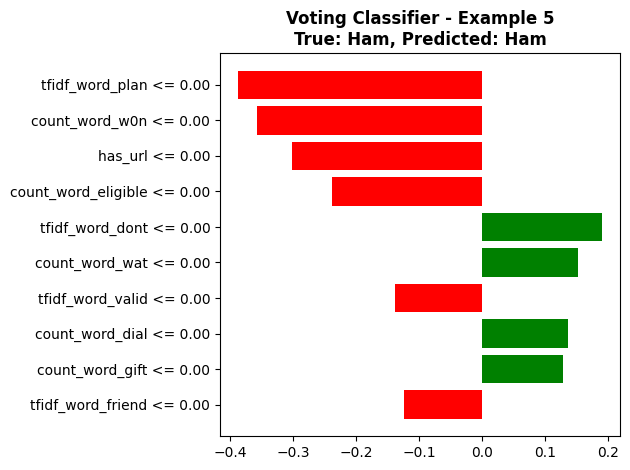


LIME analysis completed for Voting Classifier

LIME Analysis: Stacking

--- Example 1 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.995)

  Top 10 Contributing Features:
     1. count_word_yummy <= 0.00                     : -0.4139 → Ham
     2. count_word_txt <= 0.00                       : -0.3723 → Ham
     3. meta_char_count <= -0.82                     : -0.3599 → Ham
     4. tfidf_word_data <= 0.00                      : -0.3478 → Ham
     5. count_word_message <= 0.00                   : -0.3147 → Ham
     6. has_url <= 0.00                              : -0.2770 → Ham
     7. tfidf_word_sm <= 0.00                        : -0.2596 → Ham
     8. count_word_use <= 0.00                       : -0.2570 → Ham
     9. tfidf_word_hungry <= 0.00                    : -0.2071 → Ham
    10. tfidf_word_tata <= 0.00                      : -0.0784 → Ham

  Generating visualization...


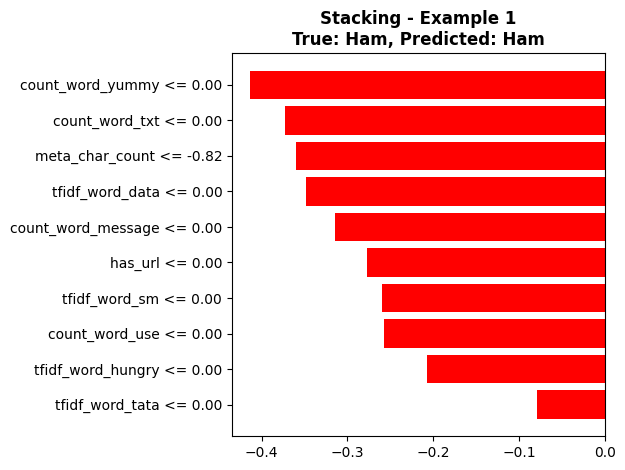


--- Example 2 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.995)

  Top 10 Contributing Features:
     1. meta_char_count <= -0.82                     : -0.3811 → Ham
     2. count_word_max <= 0.00                       : -0.3724 → Ham
     3. count_word_summer <= 0.00                    : -0.3377 → Ham
     4. tfidf_word_leh <= 0.00                       : +0.3195 → Smishing
     5. count_word_offer <= 0.00                     : -0.3092 → Ham
     6. meta_suspicious_word_count <= -0.45          : -0.2225 → Ham
     7. count_word_last <= 0.00                      : -0.2212 → Ham
     8. count_word_mention <= 0.00                   : +0.1976 → Smishing
     9. tfidf_word_money <= 0.00                     : +0.1894 → Smishing
    10. tfidf_word_help <= 0.00                      : +0.1823 → Smishing

  Generating visualization...


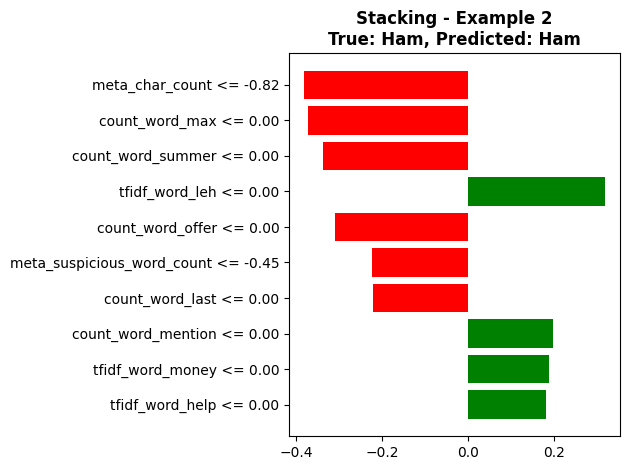


--- Example 3 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.995)

  Top 10 Contributing Features:
     1. tfidf_word_lot <= 0.00                       : -0.4051 → Ham
     2. meta_char_count <= -0.82                     : -0.4012 → Ham
     3. tfidf_word_others <= 0.00                    : -0.3343 → Ham
     4. count_word_bid <= 0.00                       : -0.3240 → Ham
     5. count_word_sm <= 0.00                        : -0.3043 → Ham
     6. count_word_fine <= 0.00                      : +0.2766 → Smishing
     7. tfidf_word_bonus <= 0.00                     : -0.2491 → Ham
     8. tfidf_word_hero <= 0.00                      : -0.1287 → Ham
     9. tfidf_word_your <= 0.00                      : -0.1220 → Ham
    10. count_word_dont <= 0.00                      : -0.0709 → Ham

  Generating visualization...


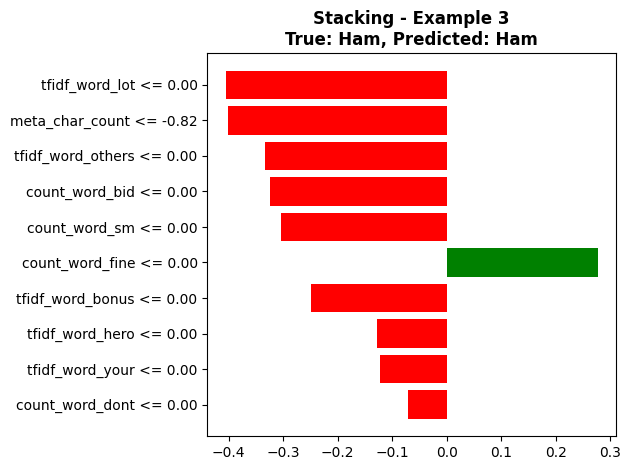


--- Example 4 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.994)

  Top 10 Contributing Features:
     1. count_word_rather <= 0.00                    : -0.4951 → Ham
     2. count_word_wrong <= 0.00                     : -0.4370 → Ham
     3. tfidf_word_glo <= 0.00                       : -0.3486 → Ham
     4. count_word_valid <= 0.00                     : -0.3118 → Ham
     5. tfidf_word_hahaha <= 0.00                    : -0.2799 → Ham
     6. count_word_tca <= 0.00                       : -0.2663 → Ham
     7. tfidf_word_randomly <= 0.00                  : +0.2388 → Smishing
     8. count_word_take <= 0.00                      : +0.1781 → Smishing
     9. tfidf_word_style <= 0.00                     : -0.1118 → Ham
    10. count_word_time <= 0.00                      : -0.0719 → Ham

  Generating visualization...


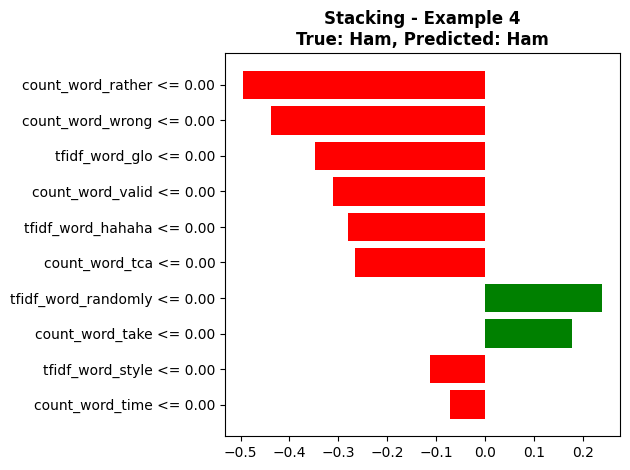


--- Example 5 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.995)

  Top 10 Contributing Features:
     1. count_word_age <= 0.00                       : -0.3026 → Ham
     2. tfidf_word_well <= 0.00                      : -0.2949 → Ham
     3. -0.82 < meta_char_count <= -0.35             : -0.2910 → Ham
     4. tfidf_word_bank <= 0.00                      : +0.2780 → Smishing
     5. count_word_sm <= 0.00                        : -0.2357 → Ham
     6. has_url <= 0.00                              : -0.2293 → Ham
     7. count_word_reply <= 0.00                     : -0.2216 → Ham
     8. count_word_wan <= 0.00                       : +0.2014 → Smishing
     9. tfidf_word_lol <= 0.00                       : +0.1947 → Smishing
    10. meta_suspicious_word_count <= -0.45          : -0.1765 → Ham

  Generating visualization...


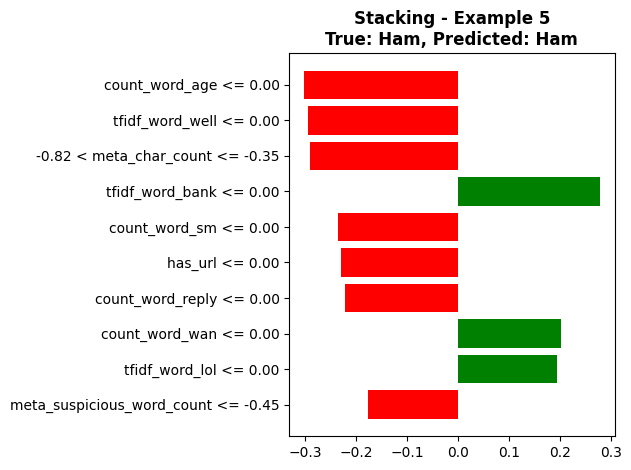


LIME analysis completed for Stacking

LIME Analysis: Random Forest

--- Example 1 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.977)

  Top 10 Contributing Features:
     1. count_word_won <= 0.00                       : -0.1418 → Ham
     2. has_url <= 0.00                              : -0.1351 → Ham
     3. count_word_pmpm <= 0.00                      : +0.1329 → Smishing
     4. tfidf_word_offer <= 0.00                     : -0.1175 → Ham
     5. tfidf_word_delivery <= 0.00                  : -0.1093 → Ham
     6. count_word_service <= 0.00                   : -0.1053 → Ham
     7. tfidf_word_lol <= 0.00                       : +0.0772 → Smishing
     8. tfidf_word_got <= 0.00                       : +0.0767 → Smishing
     9. count_word_your <= 0.00                      : -0.0673 → Ham
    10. count_word_yeah <= 0.00                      : +0.0559 → Smishing

  Generating visualization...


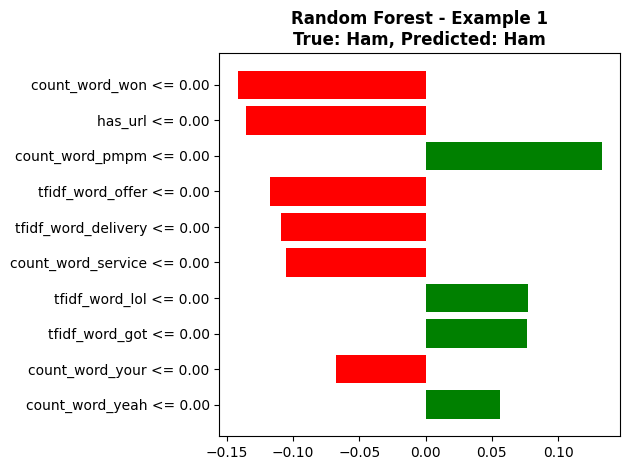


--- Example 2 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. has_url <= 0.00                              : -0.1379 → Ham
     2. tfidf_word_data <= 0.00                      : -0.1328 → Ham
     3. tfidf_word_app <= 0.00                       : -0.1113 → Ham
     4. tfidf_word_prize <= 0.00                     : -0.0862 → Ham
     5. count_word_customer <= 0.00                  : -0.0851 → Ham
     6. tfidf_word_click <= 0.00                     : -0.0836 → Ham
     7. count_word_link <= 0.00                      : -0.0693 → Ham
     8. count_word_account <= 0.00                   : -0.0647 → Ham
     9. meta_word_count <= -0.83                     : -0.0503 → Ham
    10. meta_suspicious_word_count <= -0.45          : -0.0503 → Ham

  Generating visualization...


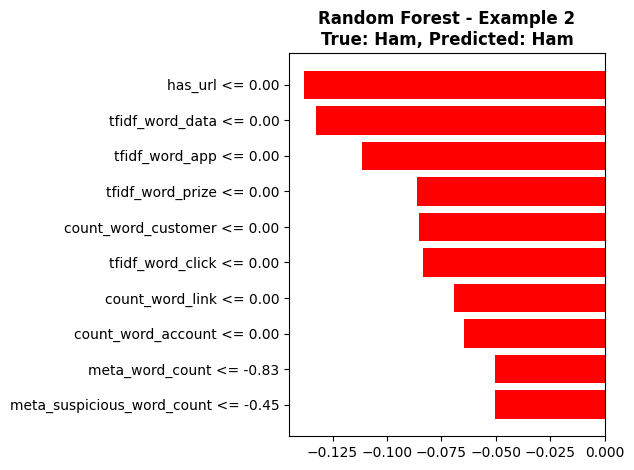


--- Example 3 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. tfidf_word_mum <= 0.00                       : -0.1401 → Ham
     2. has_url <= 0.00                              : -0.1255 → Ham
     3. tfidf_word_min <= 0.00                       : -0.1168 → Ham
     4. tfidf_word_link <= 0.00                      : -0.1149 → Ham
     5. tfidf_word_app <= 0.00                       : -0.1104 → Ham
     6. tfidf_word_offer <= 0.00                     : -0.1013 → Ham
     7. count_word_service <= 0.00                   : -0.0799 → Ham
     8. count_word_customer <= 0.00                  : -0.0724 → Ham
     9. tfidf_word_customer <= 0.00                  : -0.0611 → Ham
    10. meta_suspicious_word_count <= -0.45          : -0.0499 → Ham

  Generating visualization...


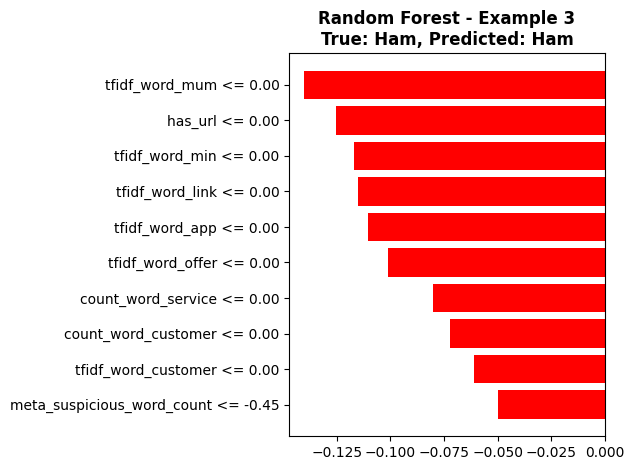


--- Example 4 ---
  True Label: Ham
  Predicted: Ham (confidence: 0.882)

  Top 10 Contributing Features:
     1. count_word_claim <= 0.00                     : -0.1199 → Ham
     2. tfidf_word_order <= 0.00                     : -0.1125 → Ham
     3. count_word_blackberry <= 0.00                : +0.1076 → Smishing
     4. has_url <= 0.00                              : -0.1038 → Ham
     5. tfidf_word_apply <= 0.00                     : -0.0969 → Ham
     6. count_word_bid <= 0.00                       : -0.0946 → Ham
     7. count_word_attach <= 0.00                    : +0.0886 → Smishing
     8. count_word_your <= 0.00                      : -0.0835 → Ham
     9. count_word_click <= 0.00                     : -0.0753 → Ham
    10. tfidf_word_click <= 0.00                     : -0.0522 → Ham

  Generating visualization...


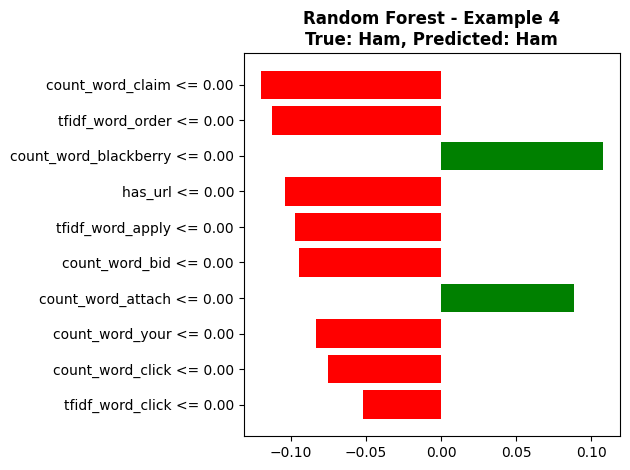


--- Example 5 ---
  True Label: Ham
  Predicted: Ham (confidence: 1.000)

  Top 10 Contributing Features:
     1. has_url <= 0.00                              : -0.1355 → Ham
     2. tfidf_word_service <= 0.00                   : -0.1148 → Ham
     3. count_word_customer <= 0.00                  : -0.1112 → Ham
     4. count_word_link <= 0.00                      : -0.1055 → Ham
     5. count_word_immediately <= 0.00               : -0.1001 → Ham
     6. tfidf_word_data <= 0.00                      : -0.0994 → Ham
     7. count_word_click <= 0.00                     : -0.0991 → Ham
     8. tfidf_word_update <= 0.00                    : -0.0761 → Ham
     9. meta_suspicious_word_count <= -0.45          : -0.0612 → Ham
    10. count_word_your <= 0.00                      : -0.0568 → Ham

  Generating visualization...


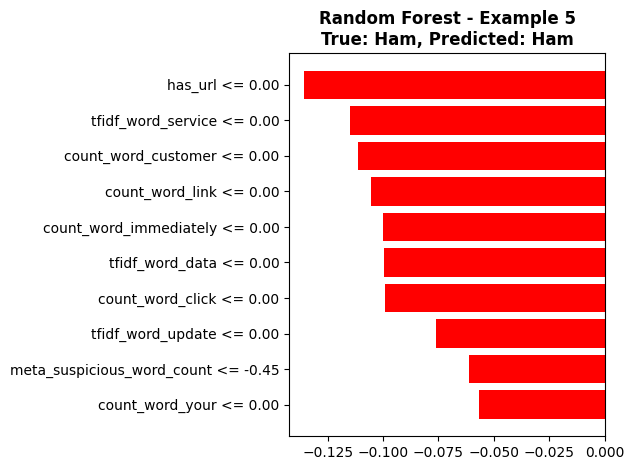


LIME analysis completed for Random Forest


In [ ]:
lime_results = {}

n_examples = 5
example_indices = np.random.choice(len(X_test_dense), n_examples, replace=False)

print(f"\nAnalyzing {n_examples} random examples across all models")

all_models_dict = {**ml_results, **ensemble_results}

for model_name, model_info in all_models_dict.items():
    print(f"\n{'='*80}")
    print(f"LIME Analysis: {model_name}")
    print(f"{'='*80}")

    model = model_info['model']
    lime_results[model_name] = {'examples': []}

    try:
        for idx, example_idx in enumerate(example_indices, 1):
            instance = X_test_dense[example_idx]
            true_label = y_test_xai[example_idx]

            pred_proba = model.predict_proba(X_test_xai[example_idx].reshape(1, -1))[0]
            pred_label = np.argmax(pred_proba)

            print(f"\n--- Example {idx} ---")
            print(f"  True Label: {'Smishing' if true_label == 1 else 'Ham'}")
            print(f"  Predicted: {'Smishing' if pred_label == 1 else 'Ham'} (confidence: {pred_proba[pred_label]:.3f})")

            def predict_fn(X):
                if hasattr(X_test_xai, 'toarray'):
                    from scipy.sparse import csr_matrix
                    X_sparse = csr_matrix(X)
                    return model.predict_proba(X_sparse)
                return model.predict_proba(X)

            explanation = lime_explainer.explain_instance(
                instance,
                predict_fn,
                num_features=10,
                num_samples=500
            )

            lime_results[model_name]['examples'].append({
                'index': example_idx,
                'true_label': true_label,
                'pred_label': pred_label,
                'pred_proba': pred_proba,
                'explanation': explanation
            })

            print(f"\n  Top 10 Contributing Features:")
            exp_list = explanation.as_list()
            for i, (feat, weight) in enumerate(exp_list[:10], 1):
                direction = "→ Smishing" if weight > 0 else "→ Ham"
                print(f"    {i:2d}. {feat:45s}: {weight:+.4f} {direction}")

            print(f"\n  Generating visualization...")
            fig = explanation.as_pyplot_figure()
            plt.title(f'{model_name} - Example {idx}\nTrue: {"Smishing" if true_label == 1 else "Ham"}, '
                     f'Predicted: {"Smishing" if pred_label == 1 else "Ham"}',
                     fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

        print(f"\nLIME analysis completed for {model_name}")

    except Exception as e:
        print(f"\nError in LIME analysis for {model_name}: {str(e)}")
        continue